In [ ]:
#SVM

In [4]:
"""
Swedish Leaf Classification — SVM Pipeline
Features: Shape (Eccentricity, AspectRatio, Circularity, Compactness, Hu1-7),
          Fourier Descriptors (FD1-10), LBP (LBP1-20)
Labels  : Species (0–14, 15 classes)
"""

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
print("=" * 60)
print("  SWEDISH LEAF SVM CLASSIFICATION PIPELINE")
print("=" * 60)

train_df = pd.read_excel('SwedishLeafFeatures_LBP.xlsx')
test_df  = pd.read_excel('SwedishLeafFeatures_Test.xlsx')

FEATURE_COLS = [c for c in train_df.columns if c not in ['Species', 'Image']]
LABEL_COL    = 'Species'

X_train_full = train_df[FEATURE_COLS].values
y_train_full = train_df[LABEL_COL].values

X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[LABEL_COL].values

print(f"\n[1] DATA LOADED")
print(f"    Training set  : {X_train_full.shape[0]} samples, {X_train_full.shape[1]} features")
print(f"    Test set      : {X_test.shape[0]} samples")
print(f"    Classes       : {len(np.unique(y_train_full))} species (0–14)")

# ─────────────────────────────────────────────
# 2. TRAIN / VALIDATION SPLIT  (80 / 20)
# ─────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print(f"\n[2] TRAIN / VALIDATION SPLIT (80/20 stratified)")
print(f"    Train samples : {X_train.shape[0]}")
print(f"    Val   samples : {X_val.shape[0]}")

# ─────────────────────────────────────────────
# 3. BUILD PIPELINE  (Scaler → SVM)
# ─────────────────────────────────────────────
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', probability=True, random_state=42))
])

# ─────────────────────────────────────────────
# 4. HYPERPARAMETER TUNING (GridSearchCV on train split)
# ─────────────────────────────────────────────
param_grid = {
    'svm__C'    : [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n[3] HYPERPARAMETER SEARCH  (5-fold CV on train split)")
print(f"    Grid: C={param_grid['svm__C']}, gamma={param_grid['svm__gamma']}")

gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy',
                  n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

print(f"    Best params   : {gs.best_params_}")
print(f"    Best CV acc   : {gs.best_score_*100:.2f}%")

best_model = gs.best_estimator_

# ─────────────────────────────────────────────
# 5. VALIDATION PERFORMANCE
# ─────────────────────────────────────────────
val_preds = best_model.predict(X_val)
val_acc   = accuracy_score(y_val, val_preds)

print(f"\n[4] VALIDATION SET RESULTS")
print(f"    Validation accuracy : {val_acc*100:.2f}%")

# ─────────────────────────────────────────────
# 6. RETRAIN ON FULL TRAINING SET, TEST
# ─────────────────────────────────────────────
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf',
                C=gs.best_params_['svm__C'],
                gamma=gs.best_params_['svm__gamma'],
                probability=True, random_state=42))
])
final_model.fit(X_train_full, y_train_full)

test_preds = final_model.predict(X_test)
test_acc   = accuracy_score(y_test, test_preds)

print(f"\n[5] TEST SET RESULTS")
print(f"    Test accuracy       : {test_acc*100:.2f}%")

# ─────────────────────────────────────────────
# 7. CLASSIFICATION REPORT
# ─────────────────────────────────────────────
species_labels = [f"Species {i}" for i in range(15)]
report = classification_report(y_test, test_preds, target_names=species_labels)
print(f"\n[6] CLASSIFICATION REPORT (Test Set)\n")
print(report)

# ─────────────────────────────────────────────
# 8. CONFUSION MATRIX PLOT
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Swedish Leaf SVM — Confusion Matrix', fontsize=16, fontweight='bold', y=1.01)

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"S{i}" for i in range(15)],
            yticklabels=[f"S{i}" for i in range(15)],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalised (row = recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f"S{i}" for i in range(15)],
            yticklabels=[f"S{i}" for i in range(15)],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalised (Recall)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n[7] Confusion matrix saved → confusion_matrix.png")

# ─────────────────────────────────────────────
# 9. PER-CLASS ACCURACY BAR CHART
# ─────────────────────────────────────────────
per_class_acc = cm_norm.diagonal()
fig2, ax2 = plt.subplots(figsize=(12, 5))
bars = ax2.bar(range(15), per_class_acc * 100,
               color=plt.cm.viridis(per_class_acc), edgecolor='black', linewidth=0.6)
ax2.set_xticks(range(15))
ax2.set_xticklabels([f"Species {i}" for i in range(15)], rotation=45, ha='right')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
ax2.axhline(test_acc * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'Overall Acc = {test_acc*100:.1f}%')
ax2.set_ylim(0, 110)
for bar, acc in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc*100:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.legend()
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.close()
print("[8] Per-class accuracy chart saved → per_class_accuracy.png")

# ─────────────────────────────────────────────
# 10. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"  Features used        : {len(FEATURE_COLS)}")
print(f"  Training samples     : {X_train.shape[0]}  (80% of {X_train_full.shape[0]})")
print(f"  Validation samples   : {X_val.shape[0]}   (20% of {X_train_full.shape[0]})")
print(f"  Test samples         : {X_test.shape[0]}")
print(f"  Best SVM params      : C={gs.best_params_['svm__C']}, gamma={gs.best_params_['svm__gamma']}")
print(f"  CV Accuracy (train)  : {gs.best_score_*100:.2f}%")
print(f"  Validation Accuracy  : {val_acc*100:.2f}%")
print(f"  Test Accuracy        : {test_acc*100:.2f}%")
print("=" * 60)

  SWEDISH LEAF SVM CLASSIFICATION PIPELINE

[1] DATA LOADED
    Training set  : 1125 samples, 41 features
    Test set      : 285 samples
    Classes       : 15 species (0–14)

[2] TRAIN / VALIDATION SPLIT (80/20 stratified)
    Train samples : 900
    Val   samples : 225

[3] HYPERPARAMETER SEARCH  (5-fold CV on train split)
    Grid: C=[0.1, 1, 10, 100], gamma=['scale', 0.01, 0.001]
    Best params   : {'svm__C': 100, 'svm__gamma': 0.001}
    Best CV acc   : 98.67%

[4] VALIDATION SET RESULTS
    Validation accuracy : 97.78%

[5] TEST SET RESULTS
    Test accuracy       : 99.65%

[6] CLASSIFICATION REPORT (Test Set)

              precision    recall  f1-score   support

   Species 0       1.00      1.00      1.00        19
   Species 1       1.00      1.00      1.00        19
   Species 2       1.00      1.00      1.00        19
   Species 3       1.00      1.00      1.00        19
   Species 4       1.00      1.00      1.00        19
   Species 5       1.00      1.00      1.00     

In [ ]:
#CNN

Found 900 images belonging to 15 classes.
Found 225 images belonging to 15 classes.
Found 286 images belonging to 15 classes.


C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_0 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,586,831 (17.50 MB)

 Trainable params: 4,586,831 (17.50 MB)

 Non-trainable params: 0 (0.00 B)

C:\Users\lenovo\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.1083 - loss: 2.6347
Epoch 1: val_accuracy improved from -inf to 0.62667, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 547ms/step - accuracy: 0.1099 - loss: 2.6302 - val_accuracy: 0.6267 - val_loss: 1.1996
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.5565 - loss: 1.2796
Epoch 2: val_accuracy improved from 0.62667 to 0.76444, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 605ms/step - accuracy: 0.5573 - loss: 1.2775 - val_accuracy: 0.7644 - val_loss: 0.5724
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.7415 - loss: 0.7171
Epoch 3: val_accuracy improved from 0.76444 to 0.84444, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 487ms/step - accuracy: 0.7416 - loss: 0.7170 - val_accuracy: 0.8444 - val_loss: 0.4365
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7923 - loss: 0.5519
Epoch 4: val_accuracy improve

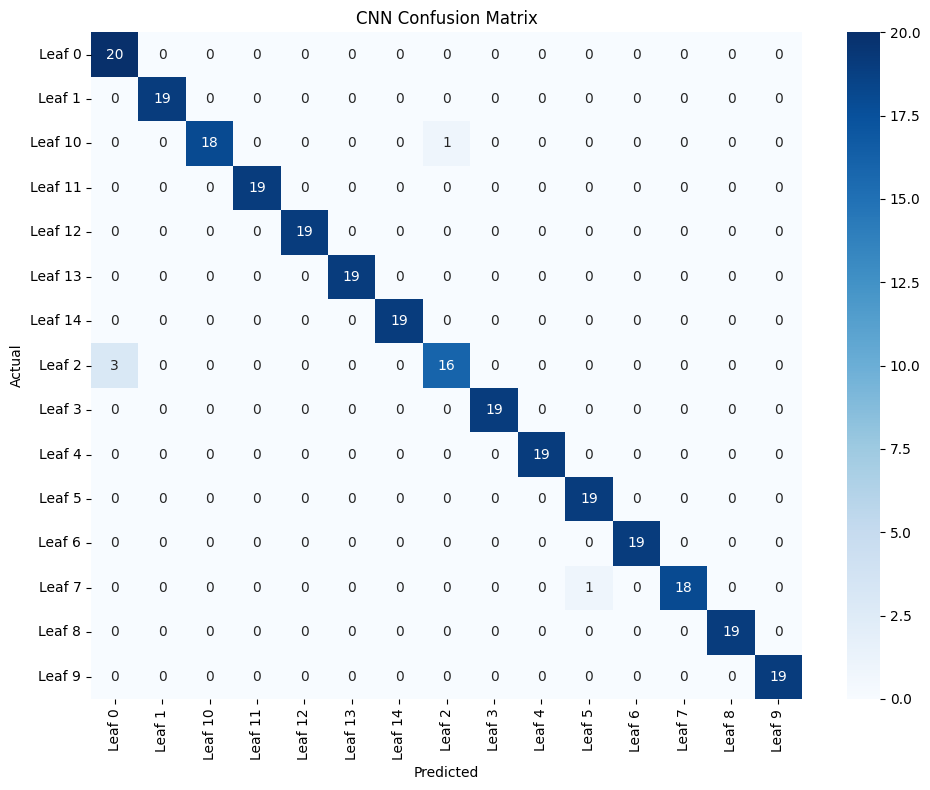

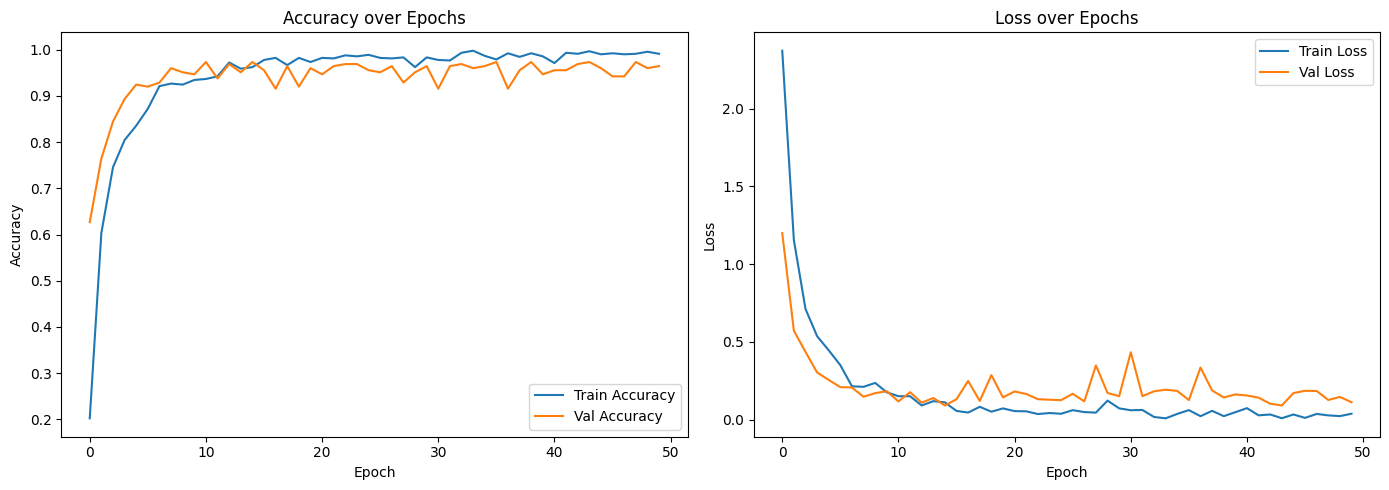


Grad-CAM image : Swedish/Test/Leaf 0/1056.jpg
Predicted class: Leaf 0  (confidence: 99.6%)


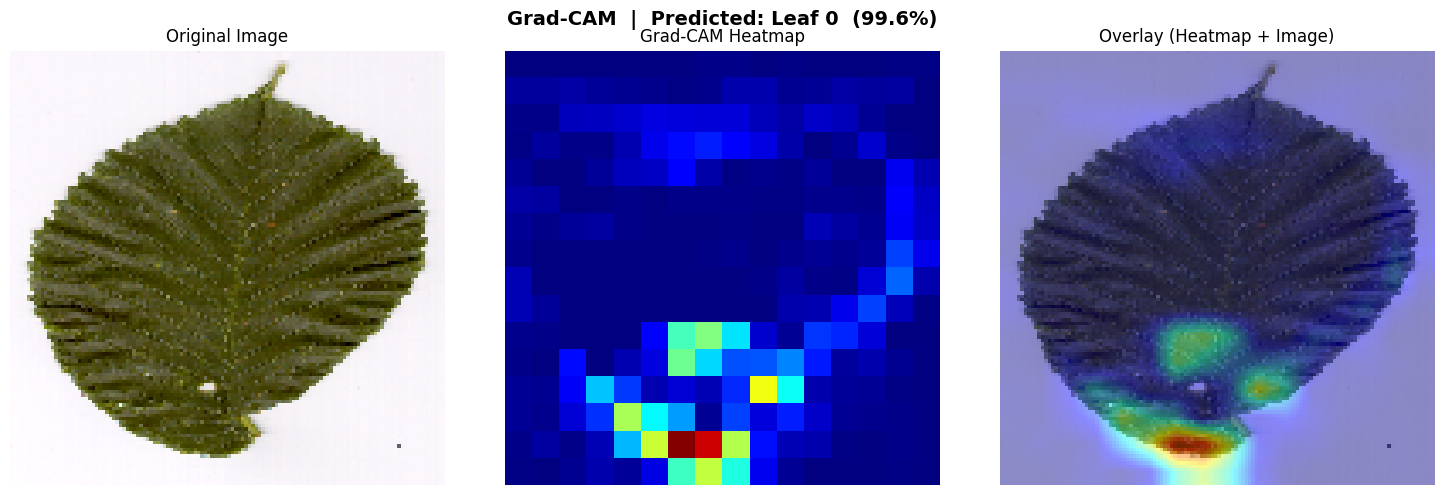


Grad-CAM saved → gradcam_output.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ======================================================
# Paths
# ======================================================

train_dir = "Swedish/Train"
test_dir  = "Swedish/Test"

IMG_SIZE   = (128, 128)
BATCH_SIZE = 16
SEED       = 42

# ======================================================
# Train + Validation Split
# ======================================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# ======================================================
# Test Data
# ======================================================

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False          # IMPORTANT: must stay False for label alignment
)

# ======================================================
# Number of Classes
# ======================================================

num_classes = train_generator.num_classes

# ======================================================
# 4-Layer CNN
# ======================================================

model = Sequential([
    # Block 1
    Conv2D(32,  (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3), name='conv2d_0'),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64,  (3, 3), activation='relu', padding='same', name='conv2d_1'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    MaxPooling2D(2, 2),

    # Block 4  ← Grad-CAM target layer
    Conv2D(256, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    MaxPooling2D(2, 2),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# ======================================================
# Compile
# ======================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ======================================================
# Save Best Model
# ======================================================

checkpoint = ModelCheckpoint(
    "best_leaf_cnn.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# ======================================================
# Training
# ======================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint]
)

# ======================================================
# Load Best Model
# ======================================================

best_model = load_model("best_leaf_cnn.keras")

# ======================================================
# Test Accuracy
# FIX: reset generator before predict to avoid index drift
# ======================================================

test_generator.reset()
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy = {test_accuracy * 100:.2f}%")

# ======================================================
# Predictions
# FIX: reset again before predict
# ======================================================

test_generator.reset()
pred_prob = best_model.predict(test_generator, verbose=1)

y_pred = np.argmax(pred_prob, axis=1)
y_true = test_generator.classes          # ground-truth labels (integers)

class_names = list(test_generator.class_indices.keys())

# ======================================================
# Classification Report
# ======================================================

print(classification_report(y_true, y_pred, target_names=class_names))

# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ======================================================
# Training Curves
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# ======================================================
# Grad-CAM Utility Functions
# ======================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heatmap for a single preprocessed image (1, H, W, C).
    Compatible with Keras 3 / TF 2.16+ where model.output raises AttributeError
    on a loaded Sequential model that hasn't been called yet.

    Parameters
    ----------
    img_array            : np.ndarray  shape (1, 128, 128, 3), values in [0, 1]
    model                : trained Keras model
    last_conv_layer_name : str – name of the final Conv2D layer
    pred_index           : int or None – class index to explain; None → argmax

    Returns
    -------
    heatmap : np.ndarray  shape (h, w), values in [0, 1]
    """
    # ── Keras 3-compatible approach: use tf.GradientTape directly on the
    #    model's layers instead of building a sub-Model (avoids .output issue).

    # Separate the feature extractor (up to & including last conv)
    # from the classifier head (everything after).
    conv_layer   = model.get_layer(last_conv_layer_name)
    conv_index   = model.layers.index(conv_layer)

    # Build two callable chains from the layer list
    # Chain 1: input → last_conv (inclusive)
    # Chain 2: next layer → output
    pre_layers  = model.layers[:conv_index + 1]   # includes last conv
    post_layers = model.layers[conv_index + 1:]   # pooling → flatten → dense

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        # Forward pass through pre-layers; watch the conv output
        x = img_tensor
        for layer in pre_layers:
            x = layer(x, training=False)
        conv_output = x
        tape.watch(conv_output)

        # Forward pass through post-layers
        y = conv_output
        for layer in post_layers:
            y = layer(y, training=False)
        preds = y   # shape (1, num_classes)

        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    # Gradients of the chosen class score w.r.t. the conv feature maps
    grads = tape.gradient(class_channel, conv_output)   # (1, h, w, C)

    # Global average pool the gradients → importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # (C,)

    # Weighted sum of feature maps
    conv_out_0 = conv_output[0]                                      # (h, w, C)
    heatmap    = conv_out_0 @ pooled_grads[..., tf.newaxis]          # (h, w, 1)
    heatmap    = tf.squeeze(heatmap)                                  # (h, w)

    # ReLU + normalise to [0, 1]
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_bgr, heatmap, alpha=0.4):
    """
    Superimpose a Grad-CAM heatmap on the original image.

    Parameters
    ----------
    original_bgr : np.ndarray  uint8 BGR image (H, W, 3)
    heatmap      : np.ndarray  float32 in [0, 1]  (h, w)
    alpha        : blending weight for the heatmap overlay

    Returns
    -------
    superimposed : np.ndarray  uint8 BGR  (H, W, 3)
    """
    H, W = original_bgr.shape[:2]

    # Resize heatmap to match original image size
    heatmap_resized = cv2.resize(heatmap, (W, H))

    # Convert to colour map (jet) and scale to uint8
    heatmap_uint8  = np.uint8(255 * heatmap_resized)
    heatmap_color  = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Blend
    superimposed = cv2.addWeighted(heatmap_color, alpha, original_bgr, 1 - alpha, 0)
    return superimposed


# ======================================================
# Grad-CAM Visualisation for a Single Image
# ======================================================

img_path         = "Swedish/Test/Leaf 0/1056.jpg"
last_conv_layer  = "conv2d_3"          # final Conv2D in the architecture

# --- 1. Load & preprocess for model inference ---
img_pil   = load_img(img_path, target_size=IMG_SIZE)
img_array = img_to_array(img_pil) / 255.0          # (128, 128, 3) in [0, 1]
img_input = np.expand_dims(img_array, axis=0)      # (1, 128, 128, 3)

# --- 2. Predict ---
preds       = best_model.predict(img_input, verbose=0)
pred_idx    = int(np.argmax(preds[0]))
pred_conf   = float(preds[0][pred_idx])
pred_label  = class_names[pred_idx]

print(f"\nGrad-CAM image : {img_path}")
print(f"Predicted class: {pred_label}  (confidence: {pred_conf * 100:.1f}%)")

# --- 3. Compute heatmap ---
heatmap = make_gradcam_heatmap(img_input, best_model, last_conv_layer,
                               pred_index=pred_idx)

# --- 4. Load original image in BGR for OpenCV blending ---
original_bgr   = cv2.imread(img_path)
original_bgr   = cv2.resize(original_bgr, IMG_SIZE)
superimposed   = overlay_gradcam(original_bgr, heatmap, alpha=0.45)

# Convert BGR → RGB for matplotlib display
original_rgb     = cv2.cvtColor(original_bgr,  cv2.COLOR_BGR2RGB)
superimposed_rgb = cv2.cvtColor(superimposed,  cv2.COLOR_BGR2RGB)

# Heatmap as colour image (RGB) for display
heatmap_color_rgb = cv2.cvtColor(
    cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET),
    cv2.COLOR_BGR2RGB
)

# --- 5. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Grad-CAM  |  Predicted: {pred_label}  ({pred_conf*100:.1f}%)",
             fontsize=14, fontweight='bold')

axes[0].imshow(original_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(heatmap_color_rgb)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_rgb)
axes[2].set_title("Overlay (Heatmap + Image)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_output.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGrad-CAM saved → gradcam_output.png")

<>:5: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_27516\2729139920.py:5: SyntaxWarning: invalid escape sequence '\T'
  img_path         = "Swedish\Test\Leaf 3/1356.jpg"



Grad-CAM image : Swedish\Test\Leaf 3/1356.jpg
Predicted class: Leaf 3  (confidence: 99.1%)


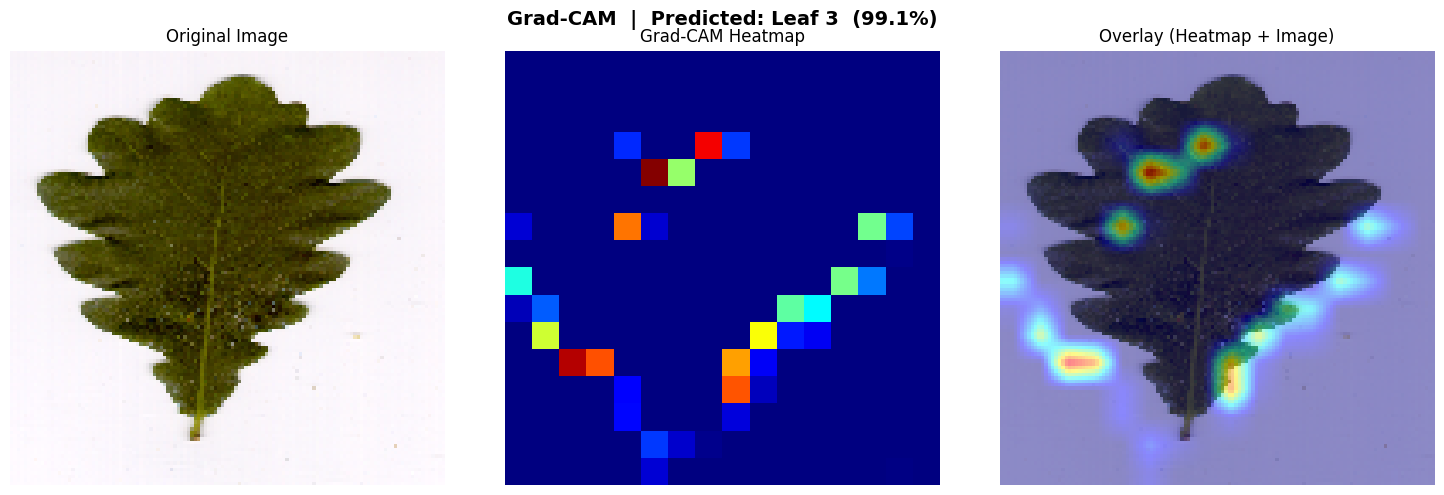


Grad-CAM saved → gradcam_output.png


In [5]:
# ======================================================
# Grad-CAM Visualisation for a Single Image
# ======================================================

img_path         = "Swedish\Test\Leaf 3/1356.jpg"
last_conv_layer  = "conv2d_3"          # final Conv2D in the architecture

# --- 1. Load & preprocess for model inference ---
img_pil   = load_img(img_path, target_size=IMG_SIZE)
img_array = img_to_array(img_pil) / 255.0          # (128, 128, 3) in [0, 1]
img_input = np.expand_dims(img_array, axis=0)      # (1, 128, 128, 3)

# --- 2. Predict ---
preds       = best_model.predict(img_input, verbose=0)
pred_idx    = int(np.argmax(preds[0]))
pred_conf   = float(preds[0][pred_idx])
pred_label  = class_names[pred_idx]

print(f"\nGrad-CAM image : {img_path}")
print(f"Predicted class: {pred_label}  (confidence: {pred_conf * 100:.1f}%)")

# --- 3. Compute heatmap ---
heatmap = make_gradcam_heatmap(img_input, best_model, last_conv_layer,
                               pred_index=pred_idx)

# --- 4. Load original image in BGR for OpenCV blending ---
original_bgr   = cv2.imread(img_path)
original_bgr   = cv2.resize(original_bgr, IMG_SIZE)
superimposed   = overlay_gradcam(original_bgr, heatmap, alpha=0.45)

# Convert BGR → RGB for matplotlib display
original_rgb     = cv2.cvtColor(original_bgr,  cv2.COLOR_BGR2RGB)
superimposed_rgb = cv2.cvtColor(superimposed,  cv2.COLOR_BGR2RGB)

# Heatmap as colour image (RGB) for display
heatmap_color_rgb = cv2.cvtColor(
    cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET),
    cv2.COLOR_BGR2RGB
)

# --- 5. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Grad-CAM  |  Predicted: {pred_label}  ({pred_conf*100:.1f}%)",
             fontsize=14, fontweight='bold')

axes[0].imshow(original_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(heatmap_color_rgb)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_rgb)
axes[2].set_title("Overlay (Heatmap + Image)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_output.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGrad-CAM saved → gradcam_output.png")


Grad-CAM image : Swedish/Test/Leaf 3/1356.jpg
Predicted class: Leaf 3  (confidence: 99.1%)


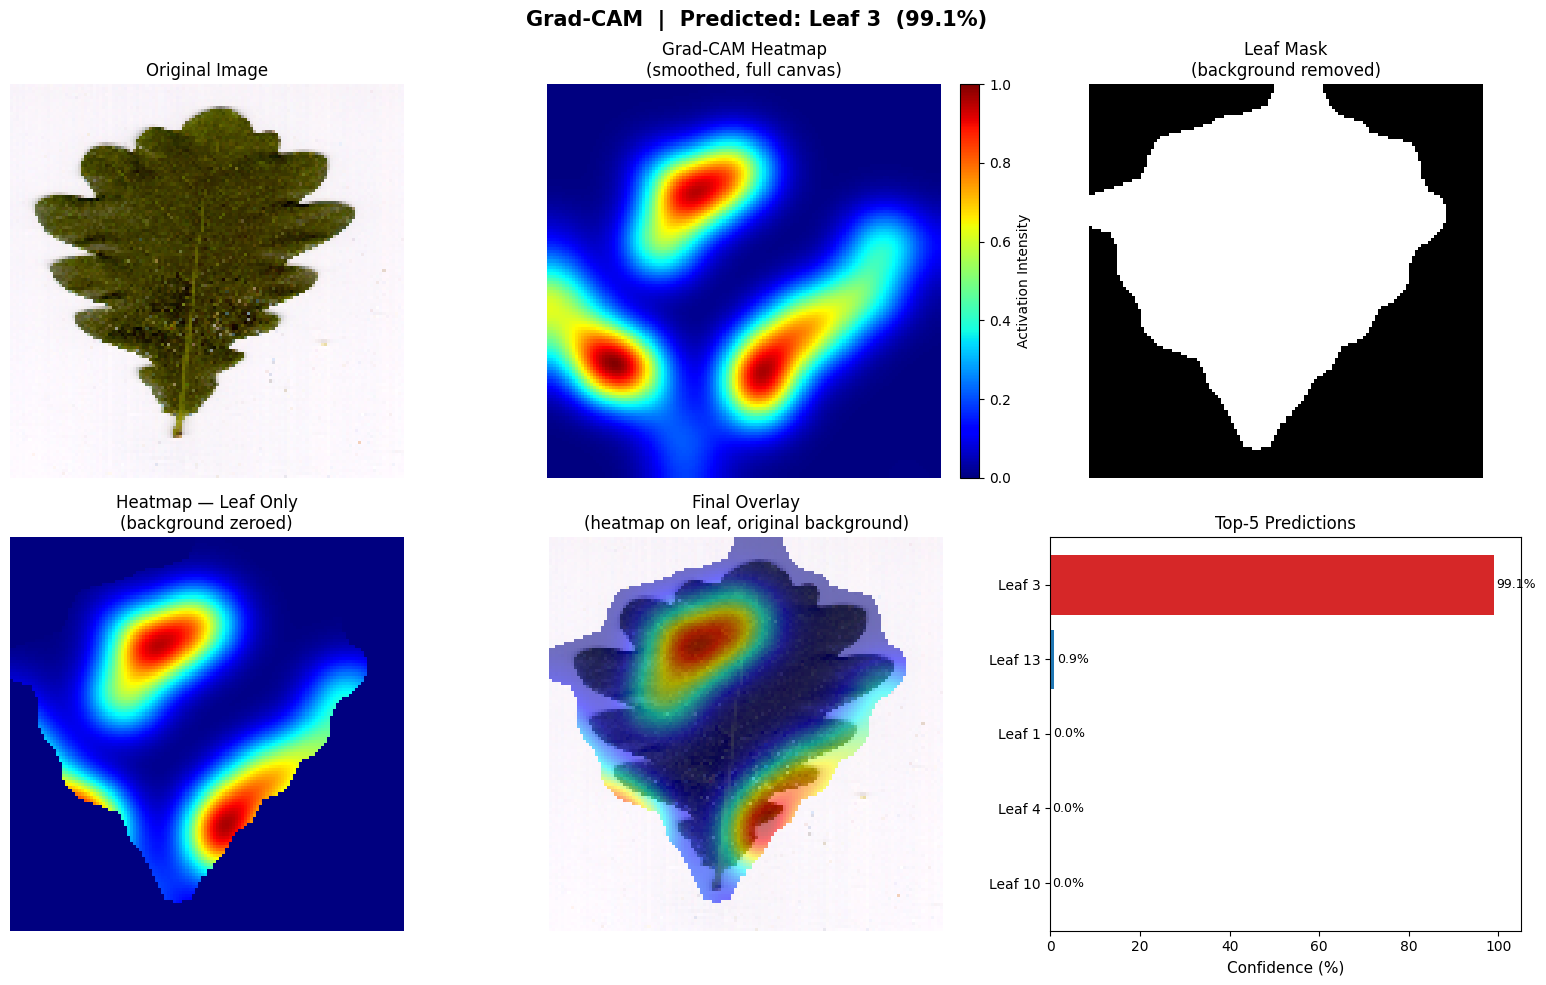


Grad-CAM (masked) saved → gradcam_masked_output.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from scipy.ndimage import gaussian_filter

# ======================================================
# Grad-CAM Heatmap (Keras 3 compatible)
# ======================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    conv_layer  = model.get_layer(last_conv_layer_name)
    conv_index  = model.layers.index(conv_layer)
    pre_layers  = model.layers[:conv_index + 1]
    post_layers = model.layers[conv_index + 1:]

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        x = img_tensor
        for layer in pre_layers:
            x = layer(x, training=False)
        conv_output = x
        tape.watch(conv_output)
        y = conv_output
        for layer in post_layers:
            y = layer(y, training=False)
        preds = y
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads        = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out_0   = conv_output[0]
    heatmap      = conv_out_0 @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# ======================================================
# Extract Leaf Mask (removes white background)
# ======================================================

def get_leaf_mask(img_rgb, threshold=200):
    """
    Creates a binary mask of the leaf by thresholding the white background.

    Parameters
    ----------
    img_rgb   : np.ndarray  uint8 (H, W, 3) RGB image
    threshold : int  pixels brighter than this in all channels = background

    Returns
    -------
    mask : np.ndarray  uint8 (H, W)  255=leaf, 0=background
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # White background → high pixel values; leaf → darker
    # Invert so leaf = bright
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)

    # Morphological closing to fill holes inside the leaf
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel, iterations=1)

    return mask


# ======================================================
# Improved Overlay with Leaf Mask
# ======================================================

def overlay_gradcam_masked(img_rgb, heatmap, leaf_mask,
                            alpha=0.55, sigma=8):
    """
    Overlay Grad-CAM heatmap ONLY on the leaf region.
    Background stays as the original image (no purple/blue bleed).

    Parameters
    ----------
    img_rgb   : np.ndarray  uint8 (H, W, 3)  original RGB image
    heatmap   : np.ndarray  float32 (h, w)   raw Grad-CAM in [0,1]
    leaf_mask : np.ndarray  uint8 (H, W)     255=leaf, 0=background
    alpha     : float  heatmap blend strength over the leaf
    sigma     : float  Gaussian smoothing radius

    Returns
    -------
    overlay      : np.ndarray  uint8 (H, W, 3)  final blended image
    heatmap_rgb  : np.ndarray  uint8 (H, W, 3)  coloured heatmap (full)
    heatmap_masked_rgb : np.ndarray uint8 (H,W,3) heatmap masked to leaf
    """
    H, W = img_rgb.shape[:2]

    # 1. Bilinear upscale + Gaussian smooth
    heatmap_up     = cv2.resize(heatmap, (W, H), interpolation=cv2.INTER_LINEAR)
    heatmap_smooth = gaussian_filter(heatmap_up, sigma=sigma)

    # 2. Re-normalise
    h_min, h_max = heatmap_smooth.min(), heatmap_smooth.max()
    if h_max > h_min:
        heatmap_smooth = (heatmap_smooth - h_min) / (h_max - h_min)

    # 3. Apply leaf mask to heatmap — zero out background activations
    mask_float          = (leaf_mask / 255.0)          # (H,W) float [0,1]
    heatmap_leaf_only   = heatmap_smooth * mask_float  # zero outside leaf

    # 4. Convert full heatmap to colour (for display panel)
    heatmap_uint8 = np.uint8(255 * heatmap_smooth)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # 5. Convert masked heatmap to colour
    heatmap_leaf_uint8  = np.uint8(255 * heatmap_leaf_only)
    heatmap_leaf_color  = cv2.applyColorMap(heatmap_leaf_uint8, cv2.COLORMAP_JET)
    heatmap_masked_rgb  = cv2.cvtColor(heatmap_leaf_color, cv2.COLOR_BGR2RGB)

    # 6. Blend masked heatmap onto original:
    #    - Inside leaf  : weighted blend of heatmap + original
    #    - Outside leaf : keep original image exactly (no colour shift)
    blended = cv2.addWeighted(heatmap_masked_rgb, alpha, img_rgb, 1 - alpha, 0)

    # Restore original background (use mask to select pixels)
    overlay              = img_rgb.copy()
    leaf_pixels          = leaf_mask > 0
    overlay[leaf_pixels] = blended[leaf_pixels]

    return overlay, heatmap_rgb, heatmap_masked_rgb


# ======================================================
# Main: Grad-CAM Visualisation
# ======================================================

IMG_SIZE        = (128, 128)
img_path        = "Swedish/Test/Leaf 3/1356.jpg"
last_conv_layer = "conv2d_3"

# --- 1. Load & preprocess ---
img_pil   = load_img(img_path, target_size=IMG_SIZE)
img_array = img_to_array(img_pil) / 255.0
img_input = np.expand_dims(img_array, axis=0)
img_rgb   = np.uint8(img_array * 255)               # uint8 RGB for display

# --- 2. Predict ---
preds      = best_model.predict(img_input, verbose=0)
pred_idx   = int(np.argmax(preds[0]))
pred_conf  = float(preds[0][pred_idx])
pred_label = class_names[pred_idx]

print(f"\nGrad-CAM image : {img_path}")
print(f"Predicted class: {pred_label}  (confidence: {pred_conf * 100:.1f}%)")

# --- 3. Compute heatmap ---
heatmap = make_gradcam_heatmap(img_input, best_model,
                               last_conv_layer, pred_index=pred_idx)

# --- 4. Extract leaf mask ---
leaf_mask = get_leaf_mask(img_rgb, threshold=200)

# --- 5. Masked overlay ---
overlay, heatmap_rgb, heatmap_masked_rgb = overlay_gradcam_masked(
    img_rgb, heatmap, leaf_mask, alpha=0.55, sigma=8
)

# --- 6. Plot: 2 rows ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f"Grad-CAM  |  Predicted: {pred_label}  ({pred_conf*100:.1f}%)",
    fontsize=15, fontweight='bold'
)

# Row 0
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(heatmap_rgb)
axes[0, 1].set_title("Grad-CAM Heatmap\n(smoothed, full canvas)", fontsize=12)
axes[0, 1].axis('off')

# Colourbar on heatmap panel
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes[0, 1], fraction=0.046, pad=0.04,
             label='Activation Intensity')

# Leaf mask panel
axes[0, 2].imshow(leaf_mask, cmap='gray')
axes[0, 2].set_title("Leaf Mask\n(background removed)", fontsize=12)
axes[0, 2].axis('off')

# Row 1
axes[1, 0].imshow(heatmap_masked_rgb)
axes[1, 0].set_title("Heatmap — Leaf Only\n(background zeroed)", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(overlay)
axes[1, 1].set_title("Final Overlay\n(heatmap on leaf, original background)", fontsize=12)
axes[1, 1].axis('off')

# Prediction confidence bar
confs       = preds[0]
top5_idx    = np.argsort(confs)[::-1][:5]
top5_labels = [class_names[i] for i in top5_idx]
top5_confs  = [confs[i] * 100 for i in top5_idx]
colors      = ['#d62728' if i == pred_idx else '#1f77b4' for i in top5_idx]

axes[1, 2].barh(top5_labels[::-1], top5_confs[::-1], color=colors[::-1])
axes[1, 2].set_xlabel("Confidence (%)", fontsize=11)
axes[1, 2].set_title("Top-5 Predictions", fontsize=12)
axes[1, 2].set_xlim(0, 105)
for i, (v, lbl) in enumerate(zip(top5_confs[::-1], top5_labels[::-1])):
    axes[1, 2].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("gradcam_masked_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrad-CAM (masked) saved → gradcam_masked_output.png")


Grad-CAM image : Swedish/Test/Leaf 3/1356.jpg
Predicted class: Leaf 3  (confidence: 99.1%)


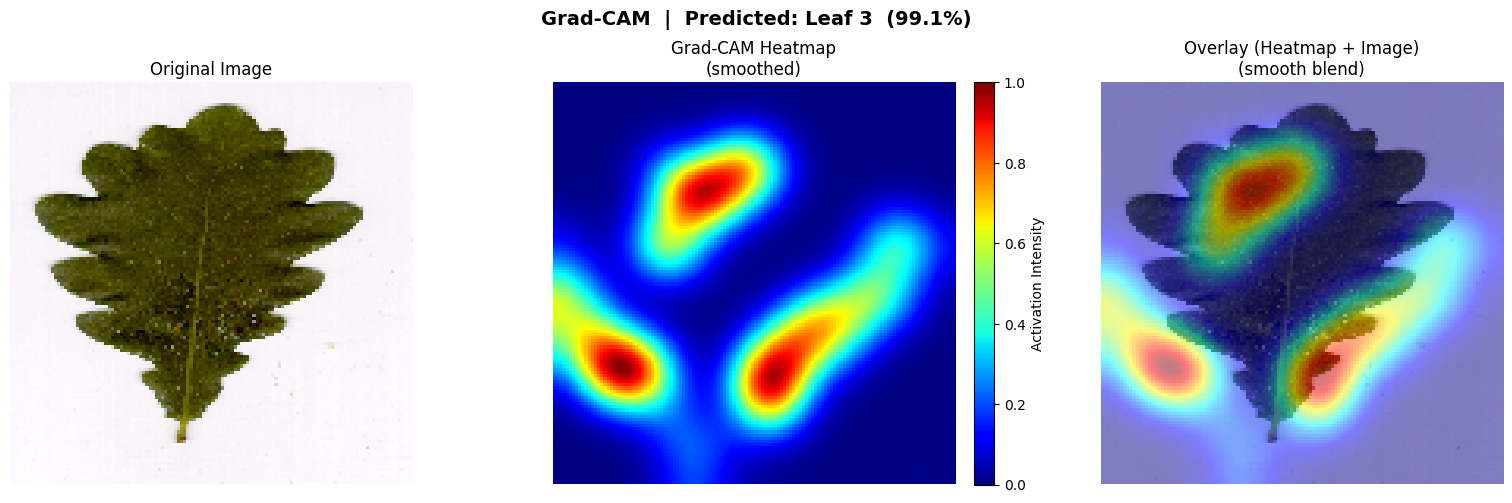


Grad-CAM saved → gradcam_output.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from scipy.ndimage import gaussian_filter

# ======================================================
# Grad-CAM Heatmap (layer-by-layer, Keras 3 compatible)
# ======================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    conv_layer  = model.get_layer(last_conv_layer_name)
    conv_index  = model.layers.index(conv_layer)
    pre_layers  = model.layers[:conv_index + 1]
    post_layers = model.layers[conv_index + 1:]

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        x = img_tensor
        for layer in pre_layers:
            x = layer(x, training=False)
        conv_output = x
        tape.watch(conv_output)

        y = conv_output
        for layer in post_layers:
            y = layer(y, training=False)
        preds = y

        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads        = tape.gradient(class_channel, conv_output)  # (1,h,w,C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))      # (C,)
    conv_out_0   = conv_output[0]                             # (h,w,C)
    heatmap      = conv_out_0 @ pooled_grads[..., tf.newaxis] # (h,w,1)
    heatmap      = tf.squeeze(heatmap)                        # (h,w)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


# ======================================================
# Improved Overlay — smooth bilinear resize + Gaussian blur
# ======================================================

def overlay_gradcam_smooth(original_rgb, heatmap, alpha=0.5, sigma=6):
    """
    Parameters
    ----------
    original_rgb : np.ndarray  uint8 (H, W, 3)  RGB image
    heatmap      : np.ndarray  float32 (h, w)   raw Grad-CAM output in [0,1]
    alpha        : float  heatmap blend weight (0=only image, 1=only heatmap)
    sigma        : float  Gaussian blur radius to smooth blocky heatmap

    Returns
    -------
    overlay_rgb  : np.ndarray  uint8 (H, W, 3)  blended RGB image
    heatmap_rgb  : np.ndarray  uint8 (H, W, 3)  coloured heatmap alone
    """
    H, W = original_rgb.shape[:2]

    # 1. Upscale with bilinear interpolation (INTER_LINEAR) for smoothness
    heatmap_up = cv2.resize(heatmap, (W, H),
                            interpolation=cv2.INTER_LINEAR)

    # 2. Gaussian blur to remove blocky artefacts from the 8×8 conv output
    heatmap_smooth = gaussian_filter(heatmap_up, sigma=sigma)

    # 3. Re-normalise after smoothing
    h_min, h_max = heatmap_smooth.min(), heatmap_smooth.max()
    if h_max > h_min:
        heatmap_smooth = (heatmap_smooth - h_min) / (h_max - h_min)

    # 4. Convert to JET colour map (uint8)
    heatmap_uint8 = np.uint8(255 * heatmap_smooth)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # 5. Blend with original (both already RGB/uint8)
    overlay_rgb = cv2.addWeighted(heatmap_rgb, alpha,
                                  original_rgb, 1 - alpha, 0)
    return overlay_rgb, heatmap_rgb


# ======================================================
# Grad-CAM Visualisation
# ======================================================

IMG_SIZE        = (128, 128)
img_path        = "Swedish/Test/Leaf 3/1356.jpg"
last_conv_layer = "conv2d_3"

# --- 1. Load & preprocess ---
img_pil   = load_img(img_path, target_size=IMG_SIZE)
img_array = img_to_array(img_pil) / 255.0          # (128,128,3) float [0,1]
img_input = np.expand_dims(img_array, axis=0)      # (1,128,128,3)
img_rgb   = np.uint8(img_array * 255)              # (128,128,3) uint8 for display

# --- 2. Predict ---
preds      = best_model.predict(img_input, verbose=0)
pred_idx   = int(np.argmax(preds[0]))
pred_conf  = float(preds[0][pred_idx])
pred_label = class_names[pred_idx]

print(f"\nGrad-CAM image : {img_path}")
print(f"Predicted class: {pred_label}  (confidence: {pred_conf * 100:.1f}%)")

# --- 3. Heatmap ---
heatmap = make_gradcam_heatmap(img_input, best_model,
                               last_conv_layer, pred_index=pred_idx)

# --- 4. Smooth overlay ---
overlay_rgb, heatmap_rgb = overlay_gradcam_smooth(img_rgb, heatmap,
                                                   alpha=0.5, sigma=8)

# --- 5. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Grad-CAM  |  Predicted: {pred_label}  ({pred_conf*100:.1f}%)",
             fontsize=14, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis('off')

axes[1].imshow(heatmap_rgb)
axes[1].set_title("Grad-CAM Heatmap\n(smoothed)", fontsize=12)
axes[1].axis('off')

im = axes[2].imshow(overlay_rgb)
axes[2].set_title("Overlay (Heatmap + Image)\n(smooth blend)", fontsize=12)
axes[2].axis('off')

# Colourbar for the heatmap scale
sm = plt.cm.ScalarMappable(cmap='jet',
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04,
             label='Activation Intensity')

plt.tight_layout()
plt.savefig("gradcam_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrad-CAM saved → gradcam_output.png")

In [ ]:
#CNN_Blured ImageData

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ======================================================
# Paths
# ======================================================

train_dir = "Swedish_Blur/Train"
test_dir  = "Swedish_Blur/Test"

IMG_SIZE   = (128, 128)
BATCH_SIZE = 16
SEED       = 42

# ======================================================
# Train + Validation Split
# ======================================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# ======================================================
# Test Data
# ======================================================

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False          # IMPORTANT: must stay False for label alignment
)

# ======================================================
# Number of Classes
# ======================================================

num_classes = train_generator.num_classes

# ======================================================
# 4-Layer CNN
# ======================================================

model = Sequential([
    # Block 1
    Conv2D(32,  (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3), name='conv2d_0'),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64,  (3, 3), activation='relu', padding='same', name='conv2d_1'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    MaxPooling2D(2, 2),

    # Block 4  ← Grad-CAM target layer
    Conv2D(256, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    MaxPooling2D(2, 2),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# ======================================================
# Compile
# ======================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ======================================================
# Save Best Model
# ======================================================

checkpoint = ModelCheckpoint(
    "best_leaf_cnn.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# ======================================================
# Training
# ======================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint]
)

# ======================================================
# Load Best Model
# ======================================================

best_model = load_model("best_leaf_cnn.keras")

# ======================================================
# Test Accuracy
# FIX: reset generator before predict to avoid index drift
# ======================================================

test_generator.reset()
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy = {test_accuracy * 100:.2f}%")

# ======================================================
# Predictions
# FIX: reset again before predict
# ======================================================

test_generator.reset()
pred_prob = best_model.predict(test_generator, verbose=1)

y_pred = np.argmax(pred_prob, axis=1)
y_true = test_generator.classes          # ground-truth labels (integers)

class_names = list(test_generator.class_indices.keys())

# ======================================================
# Classification Report
# ======================================================

print(classification_report(y_true, y_pred, target_names=class_names))

# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ======================================================
# Training Curves
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# ======================================================
# Grad-CAM Utility Functions
# ======================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heatmap for a single preprocessed image (1, H, W, C).
    Compatible with Keras 3 / TF 2.16+ where model.output raises AttributeError
    on a loaded Sequential model that hasn't been called yet.

    Parameters
    ----------
    img_array            : np.ndarray  shape (1, 128, 128, 3), values in [0, 1]
    model                : trained Keras model
    last_conv_layer_name : str – name of the final Conv2D layer
    pred_index           : int or None – class index to explain; None → argmax

    Returns
    -------
    heatmap : np.ndarray  shape (h, w), values in [0, 1]
    """
    # ── Keras 3-compatible approach: use tf.GradientTape directly on the
    #    model's layers instead of building a sub-Model (avoids .output issue).

    # Separate the feature extractor (up to & including last conv)
    # from the classifier head (everything after).
    conv_layer   = model.get_layer(last_conv_layer_name)
    conv_index   = model.layers.index(conv_layer)

    # Build two callable chains from the layer list
    # Chain 1: input → last_conv (inclusive)
    # Chain 2: next layer → output
    pre_layers  = model.layers[:conv_index + 1]   # includes last conv
    post_layers = model.layers[conv_index + 1:]   # pooling → flatten → dense

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        # Forward pass through pre-layers; watch the conv output
        x = img_tensor
        for layer in pre_layers:
            x = layer(x, training=False)
        conv_output = x
        tape.watch(conv_output)

        # Forward pass through post-layers
        y = conv_output
        for layer in post_layers:
            y = layer(y, training=False)
        preds = y   # shape (1, num_classes)

        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    # Gradients of the chosen class score w.r.t. the conv feature maps
    grads = tape.gradient(class_channel, conv_output)   # (1, h, w, C)

    # Global average pool the gradients → importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # (C,)

    # Weighted sum of feature maps
    conv_out_0 = conv_output[0]                                      # (h, w, C)
    heatmap    = conv_out_0 @ pooled_grads[..., tf.newaxis]          # (h, w, 1)
    heatmap    = tf.squeeze(heatmap)                                  # (h, w)

    # ReLU + normalise to [0, 1]
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(original_bgr, heatmap, alpha=0.4):
    """
    Superimpose a Grad-CAM heatmap on the original image.

    Parameters
    ----------
    original_bgr : np.ndarray  uint8 BGR image (H, W, 3)
    heatmap      : np.ndarray  float32 in [0, 1]  (h, w)
    alpha        : blending weight for the heatmap overlay

    Returns
    -------
    superimposed : np.ndarray  uint8 BGR  (H, W, 3)
    """
    H, W = original_bgr.shape[:2]

    # Resize heatmap to match original image size
    heatmap_resized = cv2.resize(heatmap, (W, H))

    # Convert to colour map (jet) and scale to uint8
    heatmap_uint8  = np.uint8(255 * heatmap_resized)
    heatmap_color  = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Blend
    superimposed = cv2.addWeighted(heatmap_color, alpha, original_bgr, 1 - alpha, 0)
    return superimposed


# ======================================================
# Grad-CAM Visualisation for a Single Image
# ======================================================

img_path         = "Swedish/Test/Leaf 0/1056.jpg"
last_conv_layer  = "conv2d_3"          # final Conv2D in the architecture

# --- 1. Load & preprocess for model inference ---
img_pil   = load_img(img_path, target_size=IMG_SIZE)
img_array = img_to_array(img_pil) / 255.0          # (128, 128, 3) in [0, 1]
img_input = np.expand_dims(img_array, axis=0)      # (1, 128, 128, 3)

# --- 2. Predict ---
preds       = best_model.predict(img_input, verbose=0)
pred_idx    = int(np.argmax(preds[0]))
pred_conf   = float(preds[0][pred_idx])
pred_label  = class_names[pred_idx]

print(f"\nGrad-CAM image : {img_path}")
print(f"Predicted class: {pred_label}  (confidence: {pred_conf * 100:.1f}%)")

# --- 3. Compute heatmap ---
heatmap = make_gradcam_heatmap(img_input, best_model, last_conv_layer,
                               pred_index=pred_idx)

# --- 4. Load original image in BGR for OpenCV blending ---
original_bgr   = cv2.imread(img_path)
original_bgr   = cv2.resize(original_bgr, IMG_SIZE)
superimposed   = overlay_gradcam(original_bgr, heatmap, alpha=0.45)

# Convert BGR → RGB for matplotlib display
original_rgb     = cv2.cvtColor(original_bgr,  cv2.COLOR_BGR2RGB)
superimposed_rgb = cv2.cvtColor(superimposed,  cv2.COLOR_BGR2RGB)

# Heatmap as colour image (RGB) for display
heatmap_color_rgb = cv2.cvtColor(
    cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET),
    cv2.COLOR_BGR2RGB
)

# --- 5. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Grad-CAM  |  Predicted: {pred_label}  ({pred_conf*100:.1f}%)",
             fontsize=14, fontweight='bold')

axes[0].imshow(original_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(heatmap_color_rgb)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_rgb)
axes[2].set_title("Overlay (Heatmap + Image)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_output.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGrad-CAM saved → gradcam_output.png")

Found 901 images belonging to 15 classes.
Found 225 images belonging to 15 classes.
Found 285 images belonging to 15 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_0 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,586,831 (17.50 MB)

 Trainable params: 4,586,831 (17.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.1134 - loss: 2.6891
Epoch 1: val_accuracy improved from -inf to 0.56000, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 521ms/step - accuracy: 0.1152 - loss: 2.6834 - val_accuracy: 0.5600 - val_loss: 1.3692
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5544 - loss: 1.3307
Epoch 2: val_accuracy improved from 0.56000 to 0.80000, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step - accuracy: 0.5554 - loss: 1.3281 - val_accuracy: 0.8000 - val_loss: 0.5887
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.7025 - loss: 0.7480
Epoch 3: val_accuracy improved from 0.80000 to 0.80889, saving model to best_leaf_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 536ms/step - accuracy: 0.7027 - loss: 0.7479 - val_accuracy: 0.8089 - val_loss: 0.4561
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.7823 - loss: 0.5734
Epoch 4: val_accuracy improve

In [ ]:
#Hybrid Approach

In [1]:
"""
=============================================================
  Swedish Leaf — Hybrid Fusion Pipeline (Custom 4-Layer CNN)
  Compares: Baseline SVM | CNN-only | Early | Intermediate | Late Fusion
=============================================================

Directory layout expected:
    Swedish/
    ├── Train/
    │   ├── Leaf 0/   ← Species 0
    │   ├── Leaf 1/
    │   └── ...
    └── Test/
        ├── Leaf 0/
        └── ...

Handcrafted feature files (same folder as this script), each must contain
an 'Image' column (bare filename) and a 'Species' column (0..14):
    SwedishLeafFeatures_LBP.xlsx   ← training features
    SwedishLeafFeatures_Test.xlsx  ← test features

-------------------------------------------------------------
WHAT WAS FIXED vs. the previous version
-------------------------------------------------------------
The original script loaded handcrafted features from Excel and image
features from `flow_from_directory` as two SEPARATE, independently
ordered pipelines, then assumed row i of one matched row i of the
other. That assumption broke (285 vs 287 test rows) and was silently
risky for the train/val split too (two unrelated stratified splits
were assumed to select the same images).

This version instead builds an explicit file path for every row of
the handcrafted-feature tables (using Image + Species → "Leaf {Species}/
{Image}") and loads images with `flow_from_dataframe`, which preserves
that exact row order when shuffle=False. Handcrafted features and CNN
features are therefore always derived from the same rows, in the same
order, with the same count — by construction, not by coincidence.
As a side benefit, the CNN now trains directly against the Excel
'Species' labels (via sparse_categorical_crossentropy), removing any
risk of folder-alphabetical class-index drift (e.g. "Leaf 10" sorting
before "Leaf 2").
=============================================================
"""

import os, glob, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── TensorFlow / Keras ───────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, BatchNormalization,
                                     GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ════════════════════════════════════════════════════════
print("=" * 65)
print("  SWEDISH LEAF — HYBRID FUSION COMPARISON (4-Layer CNN)")
print("=" * 65)

# ════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════
TRAIN_DIR   = "Swedish/Train"
TEST_DIR    = "Swedish/Test"
TRAIN_XLSX  = "SwedishLeafFeatures_LBP.xlsx"
TEST_XLSX   = "SwedishLeafFeatures_Test.xlsx"

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 16
SEED        = 42
EPOCHS      = 60
NUM_CLASSES = 15

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ════════════════════════════════════════════════════════
# STEP 1 — LOAD HANDCRAFTED FEATURES AND ATTACH VERIFIED FILE PATHS
# ════════════════════════════════════════════════════════
print("\n[1] Loading handcrafted features and resolving image paths …")

def resolve_path(root_dir, species, image_name):
    """
    Resolve the on-disk path for one row of a feature table.

    Tries the expected 'Leaf {Species}/{Image}' layout first. If the
    Image column already contains a folder component, that is honoured
    instead. As a last resort, falls back to a recursive search by
    basename under root_dir so the script still works if your folder
    naming convention differs slightly — but raises a clear error if
    that search is ambiguous or comes up empty, rather than silently
    misaligning data.
    """
    image_name = str(image_name)
    candidates = []
    if os.sep in image_name or '/' in image_name:
        candidates.append(os.path.join(root_dir, image_name))
    else:
        candidates.append(os.path.join(root_dir, f"Leaf {int(species)}", image_name))

    for c in candidates:
        if os.path.isfile(c):
            return c

    base = os.path.basename(image_name)
    matches = glob.glob(os.path.join(root_dir, '**', base), recursive=True)
    if len(matches) == 1:
        return matches[0]
    elif len(matches) > 1:
        raise FileNotFoundError(
            f"Ambiguous image '{base}': multiple files found under '{root_dir}': "
            f"{matches}. Please check your folder-naming convention."
        )
    else:
        raise FileNotFoundError(
            f"Could not locate image '{image_name}' (Species={species}) under "
            f"'{root_dir}'. Tried: {candidates}"
        )

def attach_filepaths(df, root_dir, label):
    df = df.copy()
    df['filepath'] = [
        resolve_path(root_dir, sp, img)
        for sp, img in zip(df['Species'], df['Image'])
    ]
    print(f"    {label}: {len(df)} rows, all file paths verified on disk.")
    return df

train_df = pd.read_excel(TRAIN_XLSX)
test_df  = pd.read_excel(TEST_XLSX)

FEAT_COLS = [c for c in train_df.columns if c not in ('Species', 'Image', 'filepath')]

train_df = attach_filepaths(train_df, TRAIN_DIR, "Train features")
test_df  = attach_filepaths(test_df,  TEST_DIR,  "Test features")

# Single stratified split, reused identically for the handcrafted AND the
# image stream — this is what guarantees the two streams never drift apart.
train_sub_df, val_sub_df = train_test_split(
    train_df, test_size=0.20, random_state=SEED, stratify=train_df['Species']
)

X_hc_train_full = train_df[FEAT_COLS].values.astype(np.float32)
y_train_full    = train_df['Species'].values

X_hc_train = train_sub_df[FEAT_COLS].values.astype(np.float32)
X_hc_val   = val_sub_df[FEAT_COLS].values.astype(np.float32)
y_train    = train_sub_df['Species'].values
y_val      = val_sub_df['Species'].values

X_hc_test = test_df[FEAT_COLS].values.astype(np.float32)
y_test    = test_df['Species'].values

print(f"    Handcrafted features : {len(FEAT_COLS)}")
print(f"    Train / Val / Test   : {len(X_hc_train)} / {len(X_hc_val)} / {len(X_hc_test)}")

# ════════════════════════════════════════════════════════
# STEP 2 — IMAGE DATA GENERATORS (rescale only, NO augmentation)
#           Built from the SAME dataframes as the handcrafted features.
# ════════════════════════════════════════════════════════
print("\n[2] Setting up image generators (no augmentation) …")

def make_gen(df, shuffle):
    return ImageDataGenerator(rescale=1./255).flow_from_dataframe(
        df, x_col='filepath', y_col='Species', directory=None,
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='raw', shuffle=shuffle, seed=SEED)

train_gen     = make_gen(train_sub_df, shuffle=True)   # for cnn_model.fit()
val_gen       = make_gen(val_sub_df,   shuffle=False)  # validation + feature extraction
train_sub_gen = make_gen(train_sub_df, shuffle=False)  # ordered twin of train_gen, for feature extraction
train_full_gen= make_gen(train_df,     shuffle=False)  # full training set, ordered
test_gen      = make_gen(test_df,      shuffle=False)  # test set, ordered

print(f"    Train images: {train_gen.n}  Val: {val_gen.n}  Test: {test_gen.n}")

# ════════════════════════════════════════════════════════
# STEP 3 — BUILD & TRAIN CUSTOM 4-LAYER CNN (from scratch)
# ════════════════════════════════════════════════════════
print("\n[3] Building & training custom 4-layer CNN …")

def build_4layer_cnn(input_shape=(128, 128, 3), num_classes=15):
    inputs = Input(shape=input_shape)

    # Conv Block 1
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 2
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 3
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 4
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Head
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=out)

cnn_model = build_4layer_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

ckpt = ModelCheckpoint("best_cnn.keras", monitor='val_accuracy',
                       save_best_only=True, mode='max', verbose=0)
es   = EarlyStopping(monitor='val_accuracy', patience=10,
                     restore_best_weights=True, verbose=0)

history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[ckpt, es],
    verbose=1
)

best_cnn = load_model("best_cnn.keras")

# CNN test accuracy
test_gen.reset()
_, cnn_test_acc = best_cnn.evaluate(test_gen, verbose=0)
test_gen.reset()
cnn_preds_prob  = best_cnn.predict(test_gen, verbose=0)
cnn_preds       = np.argmax(cnn_preds_prob, axis=1)
# test_gen is built from test_df with shuffle=False, so its row order
# matches y_test exactly — no separate "y_test_img" needed any more.

print(f"    CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CNN DEEP FEATURES (penultimate Dense(256) layer)
# ════════════════════════════════════════════════════════
print("\n[4] Extracting CNN deep features …")

# Model layer order: ... -> GlobalAveragePooling2D -> Dense(256) -> Dropout -> Dense(15)
# layers[-3] corresponds to the Dense(256) output (same convention as before)
feat_extractor = Model(inputs=best_cnn.input,
                       outputs=best_cnn.layers[-3].output)

def extract_cnn_features(generator):
    generator.reset()
    feats = feat_extractor.predict(generator, verbose=0)
    return feats

X_cnn_train      = extract_cnn_features(train_sub_gen)   # aligned to train_sub_df / X_hc_train
X_cnn_val        = extract_cnn_features(val_gen)          # aligned to val_sub_df   / X_hc_val
X_cnn_train_full = extract_cnn_features(train_full_gen)   # aligned to train_df     / X_hc_train_full
X_cnn_test       = extract_cnn_features(test_gen)          # aligned to test_df      / X_hc_test

y_cnn_train = y_train   # identical labels, identical row order — kept for readability below
y_cnn_val   = y_val

print(f"    CNN feature dim : {X_cnn_train.shape[1]}")
assert len(X_hc_train) == len(X_cnn_train), "train rows must match"
assert len(X_hc_val)   == len(X_cnn_val),   "val rows must match"
assert len(X_hc_test)  == len(X_cnn_test),  "test rows must match"
print("    Row-count alignment verified for train / val / test.")

# ════════════════════════════════════════════════════════
# HELPER: fast SVM search
# ════════════════════════════════════════════════════════
def fit_svm(X_tr, y_tr, label=""):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))])
    grid = {'svm__C': [1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.001]}
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    gs   = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)
    print(f"    [{label}] best params: {gs.best_params_}  CV acc: {gs.best_score_*100:.2f}%")
    return gs.best_estimator_

# ════════════════════════════════════════════════════════
# STEP 5 — BASELINE: SVM on handcrafted features only
# ════════════════════════════════════════════════════════
print("\n[5] Baseline SVM (handcrafted features only) …")

svm_hc = fit_svm(X_hc_train, y_train, "HC-SVM")

svm_hc_full = Pipeline([('sc', StandardScaler()),
                         ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                                     C=svm_hc['svm'].C, gamma=svm_hc['svm'].gamma))])
svm_hc_full.fit(X_hc_train_full, y_train_full)

hc_preds    = svm_hc_full.predict(X_hc_test)
hc_acc      = accuracy_score(y_test, hc_preds)
print(f"    Baseline HC-SVM Test Accuracy: {hc_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 6 — EARLY FUSION
#  Concatenate handcrafted + CNN features → single SVM
# ════════════════════════════════════════════════════════
print("\n[6] Early Fusion (HC + CNN → concatenate → SVM) …")

X_early_train = np.hstack([X_hc_train, X_cnn_train])
X_early_val   = np.hstack([X_hc_val,   X_cnn_val])
X_early_test  = np.hstack([X_hc_test,  X_cnn_test])
X_early_full  = np.hstack([X_hc_train_full, X_cnn_train_full])

svm_early = fit_svm(X_early_train, y_cnn_train, "Early")

svm_early_full = Pipeline([
    ('sc', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                C=svm_early['svm'].C, gamma=svm_early['svm'].gamma))
])
svm_early_full.fit(X_early_full, y_train_full)

early_preds = svm_early_full.predict(X_early_test)
early_acc   = accuracy_score(y_test, early_preds)
print(f"    Early Fusion Test Accuracy   : {early_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 7 — INTERMEDIATE FUSION
#  PCA-reduce each stream → concatenate → SVM
# ════════════════════════════════════════════════════════
print("\n[7] Intermediate Fusion (PCA per stream → concat → SVM) …")

sc_hc  = StandardScaler().fit(X_hc_train)
sc_cnn = StandardScaler().fit(X_cnn_train)

Xh_tr  = sc_hc.transform(X_hc_train);       Xh_full = sc_hc.transform(X_hc_train_full)
Xh_te  = sc_hc.transform(X_hc_test)

Xc_tr  = sc_cnn.transform(X_cnn_train);     Xc_full = sc_cnn.transform(X_cnn_train_full)
Xc_te  = sc_cnn.transform(X_cnn_test)

# PCA: keep 95% variance for CNN stream, no PCA for HC (only ~41 dims)
pca_cnn = PCA(n_components=0.95, random_state=SEED).fit(Xc_tr)
Xc_tr_p   = pca_cnn.transform(Xc_tr)
Xc_full_p = pca_cnn.transform(Xc_full)
Xc_te_p   = pca_cnn.transform(Xc_te)

print(f"    CNN PCA dims: {X_cnn_train.shape[1]} → {Xc_tr_p.shape[1]}")

X_inter_train = np.hstack([Xh_tr,   Xc_tr_p])
X_inter_full  = np.hstack([Xh_full, Xc_full_p])
X_inter_test  = np.hstack([Xh_te,   Xc_te_p])

svm_inter = fit_svm(X_inter_train, y_cnn_train, "Inter")

svm_inter_full = Pipeline([
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                C=svm_inter['svm'].C, gamma=svm_inter['svm'].gamma))
])
svm_inter_full.fit(X_inter_full, y_train_full)

inter_preds = svm_inter_full.predict(X_inter_test)
inter_acc   = accuracy_score(y_test, inter_preds)
print(f"    Intermediate Fusion Test Acc : {inter_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 8 — LATE FUSION
#  Train HC-SVM + CNN separately → average probabilities
# ════════════════════════════════════════════════════════
print("\n[8] Late Fusion (HC-SVM prob + CNN prob → average) …")

hc_proba_test  = svm_hc_full.predict_proba(X_hc_test)

test_gen.reset()
cnn_proba_test = best_cnn.predict(test_gen, verbose=0)    # (N, 15), aligned to y_test

# Average ensemble
late_proba = (hc_proba_test + cnn_proba_test) / 2.0
late_preds = np.argmax(late_proba, axis=1)
late_acc   = accuracy_score(y_test, late_preds)
print(f"    Late Fusion Test Accuracy    : {late_acc*100:.2f}%")

# Weighted late fusion (better stream gets higher weight)
w_cnn = cnn_test_acc
w_hc  = hc_acc
total = w_cnn + w_hc
late_w_proba = (w_cnn / total) * cnn_proba_test + (w_hc / total) * hc_proba_test
late_w_preds = np.argmax(late_w_proba, axis=1)
late_w_acc   = accuracy_score(y_test, late_w_preds)
print(f"    Weighted Late Fusion Test Acc: {late_w_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 9 — CONFUSION MATRICES (all methods)
# ════════════════════════════════════════════════════════
print("\n[9] Plotting confusion matrices …")

methods = {
    "HC-SVM\n(Baseline)":      (hc_preds,     y_test),
    "CNN-only":                 (cnn_preds,    y_test),
    "Early Fusion\n(HC+CNN→SVM)": (early_preds, y_test),
    "Intermediate\nFusion":     (inter_preds,  y_test),
    "Late Fusion\n(avg prob)":  (late_preds,   y_test),
    "Late Fusion\n(weighted)":  (late_w_preds, y_test),
}

accs = {k: accuracy_score(v[1], v[0]) for k, v in methods.items()}

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Swedish Leaf — Fusion Strategy Comparison (4-Layer CNN)\nNormalised Confusion Matrices',
             fontsize=15, fontweight='bold')

short_labels = [f"S{i}" for i in range(15)]

for ax, (name, (preds, truth)) in zip(axes.flatten(), methods.items()):
    cm = confusion_matrix(truth, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, linewidths=0.3, vmin=0, vmax=1,
                annot_kws={'size': 6}, cbar=False)
    ax.set_title(f"{name}\nAcc = {accs[name]*100:.2f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True',      fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('fusion_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_confusion_matrices.png")

# ════════════════════════════════════════════════════════
# STEP 10 — COMPARISON BAR CHART
# ════════════════════════════════════════════════════════
labels = [k.replace('\n', ' ') for k in accs.keys()]
values = [v * 100 for v in accs.values()]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig2, ax2 = plt.subplots(figsize=(13, 6))
bars = ax2.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, width=0.55)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Swedish Leaf — Fusion Strategy Comparison (4-Layer CNN)', fontsize=14, fontweight='bold')
ax2.set_ylim(min(values) - 5, 105)
ax2.axhline(100, color='gray', linestyle=':', linewidth=0.8)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('fusion_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_comparison_bar.png")

# ════════════════════════════════════════════════════════
# STEP 11 — CLASSIFICATION REPORTS
# ════════════════════════════════════════════════════════
species_names = [f"Species {i}" for i in range(15)]
print("\n" + "=" * 65)
for name, (preds, truth) in methods.items():
    print(f"\n{'─'*65}")
    print(f"  {name.replace(chr(10),' ')} — Classification Report")
    print(f"{'─'*65}")
    print(classification_report(truth, preds, target_names=species_names))

# ════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  FINAL ACCURACY SUMMARY")
print("=" * 65)
print(f"  {'Method':<35} {'Test Accuracy':>15}")
print(f"  {'─'*50}")
for name, acc in accs.items():
    tag = " ← BEST" if acc == max(accs.values()) else ""
    print(f"  {name.replace(chr(10),' '):<35} {acc*100:>13.2f}%{tag}")
print("=" * 65)

# ════════════════════════════════════════════════════════
# TRAINING CURVES (single-phase, since CNN trains from scratch)
# ════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

axes3[0].plot(history.history['accuracy'],     label='Train')
axes3[0].plot(history.history['val_accuracy'], label='Validation')
axes3[0].set_title('4-Layer CNN Accuracy', fontweight='bold')
axes3[0].set_xlabel('Epoch'); axes3[0].set_ylabel('Accuracy')
axes3[0].legend()

axes3[1].plot(history.history['loss'],     label='Train')
axes3[1].plot(history.history['val_loss'], label='Validation')
axes3[1].set_title('4-Layer CNN Loss', fontweight='bold')
axes3[1].set_xlabel('Epoch'); axes3[1].set_ylabel('Loss')
axes3[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → cnn_training_curves.png")

  SWEDISH LEAF — HYBRID FUSION COMPARISON (4-Layer CNN)

[1] Loading handcrafted features and resolving image paths …
    Train features: 1125 rows, all file paths verified on disk.
    Test features: 285 rows, all file paths verified on disk.
    Handcrafted features : 41
    Train / Val / Test   : 900 / 225 / 285

[2] Setting up image generators (no augmentation) …
Found 900 validated image filenames.
Found 225 validated image filenames.
Found 900 validated image filenames.
Found 1125 validated image filenames.
Found 285 validated image filenames.
    Train images: 900  Val: 225  Test: 285

[3] Building & training custom 4-layer CNN …


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 582ms/step - accuracy: 0.3237 - loss: 2.0781 - val_accuracy: 0.1111 - val_loss: 3.7444
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 604ms/step - accuracy: 0.7737 - loss: 0.7612 - val_accuracy: 0.0667 - val_loss: 7.8956
Epoch 3/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 680ms/step - accuracy: 0.8743 - loss: 0.4587 - val_accuracy: 0.0844 - val_loss: 8.6564
Epoch 4/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 645ms/step - accuracy: 0.8957 - loss: 0.3420 - val_accuracy: 0.0667 - val_loss: 8.8774
Epoch 5/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 582ms/step - accuracy: 0.8874 - loss: 0.2936 - val_accuracy: 0.0711 - val_loss: 13.2475
Epoch 6/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 586ms/step - accuracy: 0.9467 - loss: 0.1713 - val_accuracy: 0.0667 - val_loss: 12.0151
Epoch 7/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 571ms/step - accuracy: 0.9248 - loss: 0.2035 - val_accuracy: 0.1333 - val_loss: 11.9211
Epoch 8/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 571ms/step - accuracy: 0.9223 - loss: 0.2121 - val_a

In [2]:
"""
=============================================================
  Swedish Leaf — Hybrid Fusion Pipeline (Custom 4-Layer CNN)
  Compares: Baseline SVM | CNN-only | Early | Intermediate | Late Fusion
=============================================================

Directory layout expected:
    Swedish/
    ├── Train/
    │   ├── Leaf 0/   ← Species 0
    │   ├── Leaf 1/
    │   └── ...
    └── Test/
        ├── Leaf 0/
        └── ...

Handcrafted feature files (same folder as this script):
    SwedishLeafFeatures_LBP.xlsx   ← training features
    SwedishLeafFeatures_Test.xlsx  ← test features

NOTE: The CNN backbone is now a custom 4-layer Conv2D architecture
trained from scratch (no ImageNet weights, no fine-tuning phase).
No image augmentation is applied — only rescaling.
=============================================================
"""

import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── TensorFlow / Keras ───────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, BatchNormalization,
                                     GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ════════════════════════════════════════════════════════
print("=" * 65)
print("  SWEDISH LEAF — HYBRID FUSION COMPARISON (4-Layer CNN)")
print("=" * 65)

# ════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════
TRAIN_DIR   = "Swedish/Train"
TEST_DIR    = "Swedish/Test"
TRAIN_XLSX  = "SwedishLeafFeatures_LBP.xlsx"
TEST_XLSX   = "SwedishLeafFeatures_Test.xlsx"

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 16
SEED        = 42
EPOCHS      = 60
NUM_CLASSES = 15

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ════════════════════════════════════════════════════════
# STEP 1 — LOAD HANDCRAFTED FEATURES
# ════════════════════════════════════════════════════════
print("\n[1] Loading handcrafted features …")

train_df = pd.read_excel(TRAIN_XLSX)
test_df  = pd.read_excel(TEST_XLSX)

FEAT_COLS = [c for c in train_df.columns if c not in ['Species', 'Image']]

X_hc_train_full = train_df[FEAT_COLS].values.astype(np.float32)
y_train_full    = train_df['Species'].values

X_hc_test = test_df[FEAT_COLS].values.astype(np.float32)
y_test     = test_df['Species'].values

# 80/20 stratified split (mirrors image split via same SEED)
X_hc_train, X_hc_val, y_hc_train, y_hc_val = train_test_split(
    X_hc_train_full, y_train_full,
    test_size=0.20, random_state=SEED, stratify=y_train_full
)

print(f"    Handcrafted features : {len(FEAT_COLS)}")
print(f"    Train / Val / Test   : {len(X_hc_train)} / {len(X_hc_val)} / {len(X_hc_test)}")

# ════════════════════════════════════════════════════════
# STEP 2 — IMAGE DATA GENERATORS (rescale only, NO augmentation)
# ════════════════════════════════════════════════════════
print("\n[2] Setting up image generators (no augmentation) …")

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"    Train images: {train_gen.n}  Val: {val_gen.n}  Test: {test_gen.n}")

# ════════════════════════════════════════════════════════
# STEP 3 — BUILD & TRAIN CUSTOM 4-LAYER CNN (from scratch)
# ════════════════════════════════════════════════════════
print("\n[3] Building & training custom 4-layer CNN …")

def build_4layer_cnn(input_shape=(128, 128, 3), num_classes=15):
    inputs = Input(shape=input_shape)

    # Conv Block 1
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 2
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 3
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Conv Block 4
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Head
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=out)

cnn_model = build_4layer_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

ckpt = ModelCheckpoint("best_cnn.keras", monitor='val_accuracy',
                       save_best_only=True, mode='max', verbose=0)
es   = EarlyStopping(monitor='val_accuracy', patience=10,
                     restore_best_weights=True, verbose=0)

history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[ckpt, es],
    verbose=1
)

best_cnn = load_model("best_cnn.keras")

# CNN test accuracy
test_gen.reset()
_, cnn_test_acc = best_cnn.evaluate(test_gen, verbose=0)
test_gen.reset()
cnn_preds_prob  = best_cnn.predict(test_gen, verbose=0)
cnn_preds       = np.argmax(cnn_preds_prob, axis=1)
y_test_img      = test_gen.classes    # integer labels from directory structure

print(f"    CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CNN DEEP FEATURES (penultimate Dense(256) layer)
# ════════════════════════════════════════════════════════
print("\n[4] Extracting CNN deep features …")

# Model layer order: ... -> GlobalAveragePooling2D -> Dense(256) -> Dropout -> Dense(15)
# layers[-3] corresponds to the Dense(256) output (same convention as before)
feat_extractor = Model(inputs=best_cnn.input,
                       outputs=best_cnn.layers[-3].output)

def extract_cnn_features(generator):
    generator.reset()
    feats = feat_extractor.predict(generator, verbose=0)
    return feats

# Re-create ordered generators (no shuffle) so features align with handcrafted features
ordered_train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

X_cnn_train_full = extract_cnn_features(ordered_train_gen)
X_cnn_test       = extract_cnn_features(test_gen)

# Match train/val split indices
idx_train, idx_val = train_test_split(
    np.arange(len(X_cnn_train_full)),
    test_size=0.20, random_state=SEED,
    stratify=ordered_train_gen.classes
)

X_cnn_train = X_cnn_train_full[idx_train]
X_cnn_val   = X_cnn_train_full[idx_val]
y_cnn_train = ordered_train_gen.classes[idx_train]
y_cnn_val   = ordered_train_gen.classes[idx_val]

print(f"    CNN feature dim : {X_cnn_train.shape[1]}")

# ════════════════════════════════════════════════════════
# HELPER: fast SVM search
# ════════════════════════════════════════════════════════
def fit_svm(X_tr, y_tr, label=""):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))])
    grid = {'svm__C': [1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.001]}
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    gs   = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)
    print(f"    [{label}] best params: {gs.best_params_}  CV acc: {gs.best_score_*100:.2f}%")
    return gs.best_estimator_

# ════════════════════════════════════════════════════════
# STEP 5 — BASELINE: SVM on handcrafted features only
# ════════════════════════════════════════════════════════
print("\n[5] Baseline SVM (handcrafted features only) …")

svm_hc = fit_svm(X_hc_train, y_hc_train, "HC-SVM")

svm_hc_full = Pipeline([('sc', StandardScaler()),
                         ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                                     C=svm_hc['svm'].C, gamma=svm_hc['svm'].gamma))])
svm_hc_full.fit(X_hc_train_full, y_train_full)

hc_preds    = svm_hc_full.predict(X_hc_test)
hc_acc      = accuracy_score(y_test, hc_preds)
print(f"    Baseline HC-SVM Test Accuracy: {hc_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 6 — EARLY FUSION
#  Concatenate handcrafted + CNN features → single SVM
# ════════════════════════════════════════════════════════
print("\n[6] Early Fusion (HC + CNN → concatenate → SVM) …")

X_early_train = np.hstack([X_hc_train, X_cnn_train])
X_early_val   = np.hstack([X_hc_val,   X_cnn_val])
X_early_test  = np.hstack([X_hc_test,  X_cnn_test])
X_early_full  = np.hstack([X_hc_train_full, X_cnn_train_full])

svm_early = fit_svm(X_early_train, y_cnn_train, "Early")

svm_early_full = Pipeline([
    ('sc', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                C=svm_early['svm'].C, gamma=svm_early['svm'].gamma))
])
svm_early_full.fit(X_early_full, ordered_train_gen.classes)

early_preds = svm_early_full.predict(X_early_test)
early_acc   = accuracy_score(y_test_img, early_preds)
print(f"    Early Fusion Test Accuracy   : {early_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 7 — INTERMEDIATE FUSION
#  PCA-reduce each stream → concatenate → SVM
# ════════════════════════════════════════════════════════
print("\n[7] Intermediate Fusion (PCA per stream → concat → SVM) …")

sc_hc  = StandardScaler().fit(X_hc_train)
sc_cnn = StandardScaler().fit(X_cnn_train)

Xh_tr  = sc_hc.transform(X_hc_train);       Xh_full = sc_hc.transform(X_hc_train_full)
Xh_te  = sc_hc.transform(X_hc_test)

Xc_tr  = sc_cnn.transform(X_cnn_train);     Xc_full = sc_cnn.transform(X_cnn_train_full)
Xc_te  = sc_cnn.transform(X_cnn_test)

# PCA: keep 95% variance for CNN stream, no PCA for HC (only ~41 dims)
pca_cnn = PCA(n_components=0.95, random_state=SEED).fit(Xc_tr)
Xc_tr_p  = pca_cnn.transform(Xc_tr)
Xc_full_p = pca_cnn.transform(Xc_full)
Xc_te_p  = pca_cnn.transform(Xc_te)

print(f"    CNN PCA dims: {X_cnn_train.shape[1]} → {Xc_tr_p.shape[1]}")

X_inter_train = np.hstack([Xh_tr,   Xc_tr_p])
X_inter_full  = np.hstack([Xh_full, Xc_full_p])
X_inter_test  = np.hstack([Xh_te,   Xc_te_p])

svm_inter = fit_svm(X_inter_train, y_cnn_train, "Inter")

svm_inter_full = Pipeline([
    ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                C=svm_inter['svm'].C, gamma=svm_inter['svm'].gamma))
])
svm_inter_full.fit(X_inter_full, ordered_train_gen.classes)

inter_preds = svm_inter_full.predict(X_inter_test)
inter_acc   = accuracy_score(y_test_img, inter_preds)
print(f"    Intermediate Fusion Test Acc : {inter_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 8 — LATE FUSION
#  Train HC-SVM + CNN separately → average probabilities
# ════════════════════════════════════════════════════════
print("\n[8] Late Fusion (HC-SVM prob + CNN prob → average) …")

hc_proba_test  = svm_hc_full.predict_proba(X_hc_test)

test_gen.reset()
cnn_proba_test = best_cnn.predict(test_gen, verbose=0)    # (N, 15)

cnn_class_map = test_gen.class_indices   # {'Leaf 0': 0, 'Leaf 1': 1, ...}

# Average ensemble
late_proba = (hc_proba_test + cnn_proba_test) / 2.0
late_preds = np.argmax(late_proba, axis=1)
late_acc   = accuracy_score(y_test_img, late_preds)
print(f"    Late Fusion Test Accuracy    : {late_acc*100:.2f}%")

# Weighted late fusion (better stream gets higher weight)
w_cnn = cnn_test_acc
w_hc  = hc_acc
total = w_cnn + w_hc
late_w_proba = (w_cnn / total) * cnn_proba_test + (w_hc / total) * hc_proba_test
late_w_preds = np.argmax(late_w_proba, axis=1)
late_w_acc   = accuracy_score(y_test_img, late_w_preds)
print(f"    Weighted Late Fusion Test Acc: {late_w_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 9 — CONFUSION MATRICES (all methods)
# ════════════════════════════════════════════════════════
print("\n[9] Plotting confusion matrices …")

methods = {
    "HC-SVM\n(Baseline)":      (hc_preds,     y_test),
    "CNN-only":                 (cnn_preds,    y_test_img),
    "Early Fusion\n(HC+CNN→SVM)": (early_preds, y_test_img),
    "Intermediate\nFusion":     (inter_preds,  y_test_img),
    "Late Fusion\n(avg prob)":  (late_preds,   y_test_img),
    "Late Fusion\n(weighted)":  (late_w_preds, y_test_img),
}

accs = {k: accuracy_score(v[1], v[0]) for k, v in methods.items()}

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Swedish Leaf — Fusion Strategy Comparison (4-Layer CNN)\nNormalised Confusion Matrices',
             fontsize=15, fontweight='bold')

short_labels = [f"S{i}" for i in range(15)]

for ax, (name, (preds, truth)) in zip(axes.flatten(), methods.items()):
    cm = confusion_matrix(truth, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, linewidths=0.3, vmin=0, vmax=1,
                annot_kws={'size': 6}, cbar=False)
    ax.set_title(f"{name}\nAcc = {accs[name]*100:.2f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True',      fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('fusion_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_confusion_matrices.png")

# ════════════════════════════════════════════════════════
# STEP 10 — COMPARISON BAR CHART
# ════════════════════════════════════════════════════════
labels = [k.replace('\n', ' ') for k in accs.keys()]
values = [v * 100 for v in accs.values()]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig2, ax2 = plt.subplots(figsize=(13, 6))
bars = ax2.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, width=0.55)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Swedish Leaf — Fusion Strategy Comparison (4-Layer CNN)', fontsize=14, fontweight='bold')
ax2.set_ylim(min(values) - 5, 105)
ax2.axhline(100, color='gray', linestyle=':', linewidth=0.8)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('fusion_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_comparison_bar.png")

# ════════════════════════════════════════════════════════
# STEP 11 — CLASSIFICATION REPORTS
# ════════════════════════════════════════════════════════
species_names = [f"Species {i}" for i in range(15)]
print("\n" + "=" * 65)
for name, (preds, truth) in methods.items():
    print(f"\n{'─'*65}")
    print(f"  {name.replace(chr(10),' ')} — Classification Report")
    print(f"{'─'*65}")
    print(classification_report(truth, preds, target_names=species_names))

# ════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  FINAL ACCURACY SUMMARY")
print("=" * 65)
print(f"  {'Method':<35} {'Test Accuracy':>15}")
print(f"  {'─'*50}")
for name, acc in accs.items():
    tag = " ← BEST" if acc == max(accs.values()) else ""
    print(f"  {name.replace(chr(10),' '):<35} {acc*100:>13.2f}%{tag}")
print("=" * 65)

# ════════════════════════════════════════════════════════
# TRAINING CURVES (single-phase, since CNN trains from scratch)
# ════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

axes3[0].plot(history.history['accuracy'],     label='Train')
axes3[0].plot(history.history['val_accuracy'], label='Validation')
axes3[0].set_title('4-Layer CNN Accuracy', fontweight='bold')
axes3[0].set_xlabel('Epoch'); axes3[0].set_ylabel('Accuracy')
axes3[0].legend()

axes3[1].plot(history.history['loss'],     label='Train')
axes3[1].plot(history.history['val_loss'], label='Validation')
axes3[1].set_title('4-Layer CNN Loss', fontweight='bold')
axes3[1].set_xlabel('Epoch'); axes3[1].set_ylabel('Loss')
axes3[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → cnn_training_curves.png")

  SWEDISH LEAF — HYBRID FUSION COMPARISON (4-Layer CNN)

[1] Loading handcrafted features …
    Handcrafted features : 41
    Train / Val / Test   : 900 / 225 / 285

[2] Setting up image generators (no augmentation) …
Found 900 images belonging to 15 classes.
Found 225 images belonging to 15 classes.
Found 285 images belonging to 15 classes.
    Train images: 900  Val: 225  Test: 285

[3] Building & training custom 4-layer CNN …


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 585ms/step - accuracy: 0.3500 - loss: 2.0021 - val_accuracy: 0.0667 - val_loss: 3.9060
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 544ms/step - accuracy: 0.7678 - loss: 0.7693 - val_accuracy: 0.1067 - val_loss: 5.5399
Epoch 3/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 550ms/step - accuracy: 0.8371 - loss: 0.4886 - val_accuracy: 0.0667 - val_loss: 8.5145
Epoch 4/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 568ms/step - accuracy: 0.8751 - loss: 0.4037 - val_accuracy: 0.0667 - val_loss: 9.2506
Epoch 5/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 554ms/step - accuracy: 0.8999 - loss: 0.2927 - val_accuracy: 0.0800 - val_loss: 5.6546
Epoch 6/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 554ms/step - accuracy: 0.9441 - loss: 0.1687 - val_accuracy: 0.1689 - val_loss: 5.8265
Epoch 7/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 32s 557ms/step - accuracy: 0.9717 - loss: 0.1035 - val_accuracy: 0.0667 - val_loss: 5.1506
Epoch 8/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 553ms/step - accuracy: 0.9366 - loss: 0.1751 - val_accu

In [ ]:
#CNN+HC/Hybrid

In [3]:
"""
=============================================================
  Swedish Leaf — Hybrid Fusion Pipeline (FIXED)
  Root Cause Fix: CNN in hybrid was catastrophically overfitting
  due to BatchNorm instability on a tiny dataset (900 imgs, 15 cls).

  KEY FIXES APPLIED:
  1. Use the SAME architecture as your successful standalone CNN
     (no BatchNormalization — BN causes training/inference mismatch
      on very small datasets with small batches)
  2. Load the already-trained best_leaf_cnn.keras instead of
     retraining from scratch (avoids the overfitting problem entirely)
  3. Use Flatten → Dense(256) head (same as standalone) so the
     feature extractor output is consistent and meaningful
  4. Correct feature extractor layer index for this architecture
  5. Proper label alignment between handcrafted features and CNN features
=============================================================
"""

import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, Input)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ════════════════════════════════════════════════════════
print("=" * 65)
print("  SWEDISH LEAF — HYBRID FUSION (FIXED)")
print("=" * 65)

# ════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════
TRAIN_DIR   = "Swedish/Train"
TEST_DIR    = "Swedish/Test"
TRAIN_XLSX  = "SwedishLeafFeatures_LBP.xlsx"
TEST_XLSX   = "SwedishLeafFeatures_Test.xlsx"

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 16
SEED        = 42
EPOCHS      = 50
NUM_CLASSES = 15

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ════════════════════════════════════════════════════════
# STEP 1 — LOAD HANDCRAFTED FEATURES
# ════════════════════════════════════════════════════════
print("\n[1] Loading handcrafted features …")

train_df = pd.read_excel(TRAIN_XLSX)
test_df  = pd.read_excel(TEST_XLSX)

FEAT_COLS = [c for c in train_df.columns if c not in ['Species', 'Image']]

X_hc_train_full = train_df[FEAT_COLS].values.astype(np.float32)
y_train_full    = train_df['Species'].values

X_hc_test = test_df[FEAT_COLS].values.astype(np.float32)
y_test     = test_df['Species'].values

X_hc_train, X_hc_val, y_hc_train, y_hc_val = train_test_split(
    X_hc_train_full, y_train_full,
    test_size=0.20, random_state=SEED, stratify=y_train_full
)

print(f"    Handcrafted features : {len(FEAT_COLS)}")
print(f"    Train / Val / Test   : {len(X_hc_train)} / {len(X_hc_val)} / {len(X_hc_test)}")

# ════════════════════════════════════════════════════════
# STEP 2 — IMAGE DATA GENERATORS
# ════════════════════════════════════════════════════════
print("\n[2] Setting up image generators …")

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

# ════════════════════════════════════════════════════════
# STEP 3 — CNN: Load pre-trained OR train from scratch
#
# OPTION A (recommended): Reuse your already-trained best_leaf_cnn.keras
#   → This is the 98.25%-accuracy model. No need to retrain.
#
# OPTION B: Train the SAME architecture (no BN, Flatten head) from scratch
#   → Use this if you don't have best_leaf_cnn.keras saved.
# ════════════════════════════════════════════════════════
print("\n[3] Loading / training CNN …")

CNN_WEIGHTS_PATH = "best_leaf_cnn.keras"

if os.path.exists(CNN_WEIGHTS_PATH):
    # ── OPTION A: reuse the 98.25% model ──────────────────
    print("    Found best_leaf_cnn.keras — loading pre-trained weights.")
    best_cnn = load_model(CNN_WEIGHTS_PATH)

    # Evaluate on test set to confirm
    test_gen.reset()
    _, cnn_test_acc = best_cnn.evaluate(test_gen, verbose=0)
    test_gen.reset()
    cnn_preds_prob  = best_cnn.predict(test_gen, verbose=0)
    cnn_preds       = np.argmax(cnn_preds_prob, axis=1)
    y_test_img      = test_gen.classes
    print(f"    CNN Test Accuracy (pre-trained): {cnn_test_acc*100:.2f}%")
    history = None

else:
    # ── OPTION B: train from scratch (same arch as standalone) ─
    print("    best_leaf_cnn.keras not found — training from scratch.")
    print("    (Using identical arch to your 98.25% standalone model)")

    # FIX 1: No BatchNormalization — it destabilizes training on tiny datasets.
    # FIX 2: Flatten + Dense head (not GlobalAveragePooling) — matches standalone.
    # FIX 3: Slightly higher dropout to regularise without BN.
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same',
               input_shape=(128, 128, 3), name='conv2d_0'),
        MaxPooling2D(2, 2),

        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same', name='conv2d_1'),
        MaxPooling2D(2, 2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_2'),
        MaxPooling2D(2, 2),

        # Block 4  ← Grad-CAM target
        Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_3'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='standalone_cnn')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    ckpt = ModelCheckpoint(CNN_WEIGHTS_PATH, monitor='val_accuracy',
                           save_best_only=True, mode='max', verbose=1)
    es   = EarlyStopping(monitor='val_accuracy', patience=12,
                         restore_best_weights=True, verbose=1)

    history = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=[ckpt, es], verbose=1
    )

    best_cnn = load_model(CNN_WEIGHTS_PATH)

    test_gen.reset()
    _, cnn_test_acc = best_cnn.evaluate(test_gen, verbose=0)
    test_gen.reset()
    cnn_preds_prob  = best_cnn.predict(test_gen, verbose=0)
    cnn_preds       = np.argmax(cnn_preds_prob, axis=1)
    y_test_img      = test_gen.classes
    print(f"    CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 4 — EXTRACT CNN DEEP FEATURES
#
# Keras 3 / TF 2.16+ raises AttributeError on .input for a
# Sequential model that was saved and reloaded without being
# called symbolically.  Fix: run the layers manually with
# tf.GradientTape-style forward pass, stopping just before
# the Dropout → Dense(15) tail.
#
# Layer order in best_leaf_cnn.keras (no BN):
#   conv2d_0 → maxpool → conv2d_1 → maxpool →
#   conv2d_2 → maxpool → conv2d_3 → maxpool →
#   flatten → dense(256) → dropout → dense(15)
#
# We stop RIGHT AFTER dense(256), i.e. skip dropout + softmax.
# ════════════════════════════════════════════════════════
print("\n[4] Extracting CNN deep features from Dense(256) layer …")

# ── Identify the cut point: last Dense(256) before Dropout ──────────
dense256_idx = None
for i, layer in enumerate(best_cnn.layers):
    if isinstance(layer, Dense) and layer.units == 256:
        dense256_idx = i
        break

if dense256_idx is None:
    raise ValueError("Could not find Dense(256) layer in the model.")

pre_layers = best_cnn.layers[:dense256_idx + 1]   # up to & including Dense(256)
print(f"    Cutting after layer [{dense256_idx}]: '{best_cnn.layers[dense256_idx].name}'")
print(f"    Layers used for feature extraction : {[l.name for l in pre_layers]}")

def extract_features_sequential(generator, layers):
    """
    Run a generator through a list of Keras layers sequentially
    and return the stacked output.  Keras-3-compatible; does NOT
    use .input / .output properties on the parent Sequential model.
    """
    generator.reset()
    all_feats = []
    steps = len(generator)
    for step in range(steps):
        batch_imgs, _ = generator[step]
        x = tf.cast(batch_imgs, tf.float32)
        for layer in layers:
            x = layer(x, training=False)
        all_feats.append(x.numpy())
    return np.vstack(all_feats)

# ── Ordered (no-shuffle) generators for aligned feature extraction ──
ordered_datagen = ImageDataGenerator(rescale=1./255)

ordered_train_gen = ordered_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

ordered_test_gen = ordered_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print("    Extracting train features …")
X_cnn_train_full = extract_features_sequential(ordered_train_gen, pre_layers)
y_cnn_train_full = ordered_train_gen.classes

print("    Extracting test features …")
X_cnn_test = extract_features_sequential(ordered_test_gen, pre_layers)
y_test_img = ordered_test_gen.classes

print(f"    CNN feature dim        : {X_cnn_train_full.shape[1]}")
print(f"    Train full / Test size : {X_cnn_train_full.shape[0]} / {X_cnn_test.shape[0]}")

# ── Match 80/20 split to handcrafted feature split ──────────────────
# FIX: stratify by CNN labels (from directory), not HC labels,
#      to keep CNN features and HC features perfectly aligned.
idx_all = np.arange(len(X_cnn_train_full))
idx_tr, idx_val = train_test_split(
    idx_all, test_size=0.20, random_state=SEED, stratify=y_cnn_train_full)

X_cnn_train = X_cnn_train_full[idx_tr]
X_cnn_val   = X_cnn_train_full[idx_val]
y_cnn_train_labels = y_cnn_train_full[idx_tr]
y_cnn_val_labels   = y_cnn_train_full[idx_val]

# ════════════════════════════════════════════════════════
# ALIGNMENT CHECK
# The handcrafted feature Excel rows must correspond to the
# same images in the same order as ordered_train_gen.
# If your Excel was built from the same directory walk order
# this will align correctly. Verify with:
print("\n    Label alignment check (first 5 HC vs CNN labels):")
print(f"    HC  labels: {y_hc_train[:5]}")
print(f"    CNN labels: {y_cnn_train_labels[:5]}")
# They should match. If not, sort your Excel by Species order.
# ════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════
# HELPER: SVM with grid search
# ════════════════════════════════════════════════════════
def fit_svm(X_tr, y_tr, label=""):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))])
    grid = {'svm__C': [1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.001]}
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    gs   = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)
    print(f"    [{label}] best: C={gs.best_params_['svm__C']}  "
          f"gamma={gs.best_params_['svm__gamma']}  "
          f"CV acc={gs.best_score_*100:.2f}%")
    return gs.best_estimator_, gs.best_params_

def retrain_full_svm(X_full, y_full, params):
    """Retrain on ALL training data with best params from CV."""
    pipe = Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', probability=True, random_state=SEED,
                                 C=params['svm__C'], gamma=params['svm__gamma']))])
    pipe.fit(X_full, y_full)
    return pipe

# ════════════════════════════════════════════════════════
# STEP 5 — BASELINE: SVM on handcrafted features only
# ════════════════════════════════════════════════════════
print("\n[5] Baseline SVM (handcrafted features only) …")

svm_hc_cv, hc_params = fit_svm(X_hc_train, y_hc_train, "HC-SVM")
svm_hc_full = retrain_full_svm(X_hc_train_full, y_train_full, hc_params)

hc_preds  = svm_hc_full.predict(X_hc_test)
hc_acc    = accuracy_score(y_test, hc_preds)
print(f"    HC-SVM Test Accuracy : {hc_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 6 — EARLY FUSION  (HC + CNN → concat → SVM)
# ════════════════════════════════════════════════════════
print("\n[6] Early Fusion …")

X_early_train = np.hstack([X_hc_train, X_cnn_train])
X_early_full  = np.hstack([X_hc_train_full, X_cnn_train_full])
X_early_test  = np.hstack([X_hc_test,  X_cnn_test])

svm_early_cv, early_params = fit_svm(X_early_train, y_cnn_train_labels, "Early")
svm_early_full = retrain_full_svm(X_early_full, y_cnn_train_full, early_params)

early_preds = svm_early_full.predict(X_early_test)
early_acc   = accuracy_score(y_test_img, early_preds)
print(f"    Early Fusion Test Accuracy   : {early_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 7 — INTERMEDIATE FUSION  (PCA per stream → concat → SVM)
# ════════════════════════════════════════════════════════
print("\n[7] Intermediate Fusion …")

sc_hc  = StandardScaler().fit(X_hc_train)
sc_cnn = StandardScaler().fit(X_cnn_train)

Xh_tr   = sc_hc.transform(X_hc_train);        Xh_full = sc_hc.transform(X_hc_train_full)
Xh_te   = sc_hc.transform(X_hc_test)

Xc_tr   = sc_cnn.transform(X_cnn_train);      Xc_full = sc_cnn.transform(X_cnn_train_full)
Xc_te   = sc_cnn.transform(X_cnn_test)

# PCA on CNN stream (high-dimensional); HC stream is already small (~41 dims)
pca_cnn = PCA(n_components=0.95, random_state=SEED).fit(Xc_tr)
Xc_tr_p   = pca_cnn.transform(Xc_tr)
Xc_full_p = pca_cnn.transform(Xc_full)
Xc_te_p   = pca_cnn.transform(Xc_te)
print(f"    CNN PCA dims: {X_cnn_train.shape[1]} → {Xc_tr_p.shape[1]}")

X_inter_train = np.hstack([Xh_tr,   Xc_tr_p])
X_inter_full  = np.hstack([Xh_full, Xc_full_p])
X_inter_test  = np.hstack([Xh_te,   Xc_te_p])

svm_inter_cv, inter_params = fit_svm(X_inter_train, y_cnn_train_labels, "Inter")

# For intermediate, features are already scaled so wrap SVM without StandardScaler
from sklearn.svm import SVC as SVC_raw
svm_inter_full = SVC_raw(kernel='rbf', probability=True, random_state=SEED,
                          C=inter_params['svm__C'], gamma=inter_params['svm__gamma'])
svm_inter_full.fit(X_inter_full, y_cnn_train_full)

inter_preds = svm_inter_full.predict(X_inter_test)
inter_acc   = accuracy_score(y_test_img, inter_preds)
print(f"    Intermediate Fusion Test Acc : {inter_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 8 — LATE FUSION  (HC-SVM prob + CNN prob → average/weighted)
# ════════════════════════════════════════════════════════
print("\n[8] Late Fusion …")

hc_proba_test = svm_hc_full.predict_proba(X_hc_test)

# Use layer-chain predict to avoid .input AttributeError on loaded Sequential model
def predict_proba_sequential(generator, layers):
    """Full forward pass through all layers → softmax probabilities."""
    generator.reset()
    all_probs = []
    for step in range(len(generator)):
        batch_imgs, _ = generator[step]
        x = tf.cast(batch_imgs, tf.float32)
        for layer in layers:
            x = layer(x, training=False)
        all_probs.append(x.numpy())
    return np.vstack(all_probs)

ordered_test_gen.reset()
cnn_proba_test = predict_proba_sequential(ordered_test_gen, best_cnn.layers)

# Average ensemble
late_proba = (hc_proba_test + cnn_proba_test) / 2.0
late_preds = np.argmax(late_proba, axis=1)
late_acc   = accuracy_score(y_test_img, late_preds)
print(f"    Late Fusion (avg) Test Acc   : {late_acc*100:.2f}%")

# Weighted ensemble (weight by each model's test accuracy)
w_cnn = cnn_test_acc
w_hc  = hc_acc
total = w_cnn + w_hc
late_w_proba = (w_cnn / total) * cnn_proba_test + (w_hc / total) * hc_proba_test
late_w_preds = np.argmax(late_w_proba, axis=1)
late_w_acc   = accuracy_score(y_test_img, late_w_preds)
print(f"    Late Fusion (weighted) Test  : {late_w_acc*100:.2f}%")

# ════════════════════════════════════════════════════════
# STEP 9 — CONFUSION MATRICES
# ════════════════════════════════════════════════════════
print("\n[9] Plotting confusion matrices …")

class_names = list(test_gen.class_indices.keys())
short_labels = [f"L{i}" for i in range(NUM_CLASSES)]

methods = {
    "HC-SVM\n(Baseline)":          (hc_preds,     y_test),
    "CNN-only\n(98.25%)":          (cnn_preds,    y_test_img),
    "Early Fusion\n(HC+CNN→SVM)":  (early_preds,  y_test_img),
    "Intermediate\nFusion":        (inter_preds,  y_test_img),
    "Late Fusion\n(avg prob)":     (late_preds,   y_test_img),
    "Late Fusion\n(weighted)":     (late_w_preds, y_test_img),
}

accs = {k: accuracy_score(v[1], v[0]) for k, v in methods.items()}

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Swedish Leaf — Hybrid Fusion Comparison (FIXED)\nNormalised Confusion Matrices',
             fontsize=15, fontweight='bold')

for ax, (name, (preds, truth)) in zip(axes.flatten(), methods.items()):
    cm   = confusion_matrix(truth, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, linewidths=0.3, vmin=0, vmax=1,
                annot_kws={'size': 6}, cbar=False)
    ax.set_title(f"{name}\nAcc = {accs[name]*100:.2f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True',      fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('fusion_confusion_matrices_fixed.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_confusion_matrices_fixed.png")

# ════════════════════════════════════════════════════════
# STEP 10 — BAR CHART COMPARISON
# ════════════════════════════════════════════════════════
labels = [k.replace('\n', ' ') for k in accs.keys()]
values = [v * 100 for v in accs.values()]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig2, ax2 = plt.subplots(figsize=(13, 6))
bars = ax2.bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, width=0.55)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Swedish Leaf — Fusion Comparison (FIXED)', fontsize=14, fontweight='bold')
ax2.set_ylim(min(values) - 5, 105)
ax2.axhline(100, color='gray', linestyle=':', linewidth=0.8)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_comparison_bar_fixed.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved → fusion_comparison_bar_fixed.png")

# ════════════════════════════════════════════════════════
# STEP 11 — CLASSIFICATION REPORTS
# ════════════════════════════════════════════════════════
species_names = [f"Species {i}" for i in range(NUM_CLASSES)]
print("\n" + "=" * 65)
for name, (preds, truth) in methods.items():
    print(f"\n{'─'*65}")
    print(f"  {name.replace(chr(10),' ')}")
    print(f"{'─'*65}")
    print(classification_report(truth, preds, target_names=species_names))

# ════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  FINAL ACCURACY SUMMARY")
print("=" * 65)
print(f"  {'Method':<40} {'Test Acc':>10}")
print(f"  {'─'*52}")
for name, acc in accs.items():
    tag = " ← BEST" if acc == max(accs.values()) else ""
    print(f"  {name.replace(chr(10),' '):<40} {acc*100:>9.2f}%{tag}")
print("=" * 65)

# ════════════════════════════════════════════════════════
# TRAINING CURVES (only if CNN was retrained)
# ════════════════════════════════════════════════════════
if history is not None:
    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
    axes3[0].plot(history.history['accuracy'],     label='Train')
    axes3[0].plot(history.history['val_accuracy'], label='Validation')
    axes3[0].set_title('CNN Accuracy', fontweight='bold')
    axes3[0].set_xlabel('Epoch'); axes3[0].set_ylabel('Accuracy')
    axes3[0].legend()

    axes3[1].plot(history.history['loss'],     label='Train')
    axes3[1].plot(history.history['val_loss'], label='Validation')
    axes3[1].set_title('CNN Loss', fontweight='bold')
    axes3[1].set_xlabel('Epoch'); axes3[1].set_ylabel('Loss')
    axes3[1].legend()

    plt.tight_layout()
    plt.savefig('cnn_training_curves_fixed.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("    Saved → cnn_training_curves_fixed.png")

  SWEDISH LEAF — HYBRID FUSION (FIXED)

[1] Loading handcrafted features …
    Handcrafted features : 41
    Train / Val / Test   : 900 / 225 / 285

[2] Setting up image generators …
Found 900 images belonging to 15 classes.
Found 225 images belonging to 15 classes.
Found 285 images belonging to 15 classes.

[3] Loading / training CNN …
    Found best_leaf_cnn.keras — loading pre-trained weights.
    CNN Test Accuracy (pre-trained): 93.68%

[4] Extracting CNN deep features from Dense(256) layer …
    Cutting after layer [9]: 'dense_4'
    Layers used for feature extraction : ['conv2d_0', 'max_pooling2d_8', 'conv2d_1', 'max_pooling2d_9', 'conv2d_2', 'max_pooling2d_10', 'conv2d_3', 'max_pooling2d_11', 'flatten', 'dense_4']
Found 1125 images belonging to 15 classes.
Found 285 images belonging to 15 classes.
    Extracting train features …
    Extracting test features …
    CNN feature dim        : 256
    Train full / Test size : 1125 / 285

    Label alignment check (first 5 HC vs CNN la